# EDA

In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.dates as mdates
from IPython.display import Markdown
import warnings
warnings.filterwarnings('ignore')

**Functions**

In [2]:
#function clean date cols
def clean_date_columns(df, date_columns):
    for col in date_columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce').dt.normalize()
        elif pd.api.types.is_float_dtype(df[col]) or pd.api.types.is_integer_dtype(df[col]):
            df[col] = df[col].dropna().astype(int).astype(str).apply(lambda x: pd.to_datetime(x, format='%Y%m%d', errors='coerce'))
        else:
            df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)
            df[col] = pd.to_datetime(df[col]).dt.date.astype(str).astype('datetime64[ns]')
            #df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce').dt.normalize()
    return df

#get feats origin
def get_feature_origin(df, dict_map_descriptions):
    df_explained = pd.DataFrame({
        'Feature': df.columns,  
        'Origin': [
            'tu' if ((col == 'pmt_hx') or ('tu_pmthx' in col))
            else col.split('__')[1] if '__' in col
            else 'ENG' if 'ENG' in col else 'local'
            for col in df.columns
        ], 
        'Description': [dict_map_descriptions.get(col, 'No Description') for col in df.columns]
    })
    return df_explained

#function find missing percentage
def add_missing_percentage(df, df_explained):
    # calculate
    missing_percentages = {col: df[col].isna().sum() / len(df) * 100 for col in df.columns}
    
    # add missing percentage
    df_explained['Missing_Percentage'] = df_explained['Feature'].map(missing_percentages)
    
    return df_explained

#function assigning data types
def get_dtype(df, df_explained):
    feature_types = {'binary': [], 'numeric': [], 'string': [], 'date': [], 'id': [], 'list/dictionary': [], 'all_nan': [], 'other':[]}
    invalid_id_words = ['provide', 'valid', 'evidence']
    
    for feature in df.columns:
        # based on description
        if feature == 'inputprovideddateofbirth__ln':
            feature_types['binary'].append(feature)
            #print(f"Feature '{feature}' has 1 unique value and NaN values; treating as 'binary' (need to convert to 0/1s).\n")
            continue
        # dict/list
        elif feature.lower() == 'pmt_hx' or 'list' in feature.lower() or ('tu_pmthx' in feature.lower() and pd.api.types.is_string_dtype(df[feature])):
            feature_types['list/dictionary'].append(feature)
            #print(f"Feature '{feature}' is classified as 'other' feature.")
            #print(f"Reason: The feature is either in dictionary or list form.\n")
            continue
        # date
        elif any(keyword in feature.lower() for keyword in ['date', 'stamp', 'dtm']):
            feature_types['date'].append(feature)
            #print(f"Feature '{feature}' is classified as 'date' feature regardless of its dtype.")
            #print(f"Reason: The feature name contains a date-related keyword ('date', 'stamp', 'dtm').\n")
            continue

        # id
        elif 'id' in feature.lower() and not any(word in feature.lower() for word in invalid_id_words):
            feature_types['id'].append(feature)
            #print(f"Feature '{feature}' is classified as 'id' feature.")
            #print(f"Reason: The feature name contains 'id'.\n")
            continue

        
        # all nan features
        elif df_explained[df_explained['Feature']==feature]['Missing_Percentage'].values[0]==100:
            feature_types['all_nan'].append(feature)
            #print(f"Feature '{feature}' is classified as 'other' feature.")
            #print(f"Reason: The feature has no values.\n")   
            continue
            
        # date-- just in case
        elif pd.api.types.is_datetime64_any_dtype(df[feature]):
            feature_types['date'].append(feature)
            #print(f"Feature '{feature}' is classified as 'date' feature based on dtype.")
            #print(f"Reason: The feature is of datetime dtype.\n")   
            continue
            
        # numeric/string
        if df[feature].dtype in [np.int64, np.float64]:
            if df[feature].nunique() == 2:
                feature_types['binary'].append(feature)
            elif df[feature].nunique() == 1 and df[feature].isna().sum() > 0:
                #print(f"Feature '{feature}' has 1 unique value and NaN values; treating as 'binary' (need to convert to 0/1s).\n")
                feature_types['binary'].append(feature)
#             elif df[feature].nunique() < 10:
#                 feature_types['unique'].append(feature)
            else:
                feature_types['numeric'].append(feature)
        elif pd.api.types.is_string_dtype(df[feature]):
            if df[feature].nunique() == 2:
                feature_types['binary'].append(feature)
                #print(f"Feature '{feature}' is classified as 'binary' with values {df[feature].unique()[0]} and {df[feature].unique()[1]}.\n")
            elif df[feature].nunique() == 1 and df[feature].isna().sum() > 0:
                #print(f"Feature '{feature}' has 1 unique value and NaN values; treating as 'binary' (need to convert to 0/1s).\n")
                feature_types['binary'].append(feature)
#             elif df[feature].nunique() < 10:
#                 feature_types['unique'].append(feature)
            else:
                feature_types['string'].append(feature)
        # Other
        else:
            feature_types['other'].append(feature)
            #print(f"Feature '{feature}' is classified as 'other' feature.")
            #print(f"Reason: The feature has a dtype of {df[feature].dtype} and does not match other categories.\n")
    
    return feature_types

#get negative values percentage -- set conditions for string
def get_negative_percentage(df, col):
    if df[col].dtype == 'object' and set(df[col].dropna().unique()) <= {True, False, 'True', 'False'}:
        count_negative = 0
    elif df[col].dtype in ['int64', 'float64']:
        count_negative = (df[col] < 0).sum()
    elif df[col].dtype == 'object':
        count_negative = df[col].str.match(r'-\d+(\.\d+)?$').sum()
    else:
        count_negative = 0
    
    total_count = len(df[col])
    negative_proportion= count_negative / total_count
    return negative_proportion

#add stats for col based on data type
def add_stats(df, df_explained, dict_date):

    def get_stats(row):
        feature = row['Feature']
        feature_type = row['Type']
        
        #binary
        if feature_type == 'binary':
            #get feature info
            unique_values = df[feature].dropna().unique()
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            negative_percentage = get_negative_percentage(df, feature)
            
            if len(unique_values) == 1:  #if one unique
                return {"Nunique":len(unique_values),
                        "Values":{
                    unique_values[0]: df[feature].value_counts().to_dict().get(unique_values[0], 0),
                    "NaN": df[feature].isna().sum()},
                       "Nan_percentage":nan_percentage,
                       "Negative_percentage":negative_percentage}
            elif len(unique_values) == 2:  #two unique-- binary
                return {"Nunique":len(unique_values),
                        "Values":df[feature].value_counts(dropna=False).to_dict(),
                        "Nan_percentage":nan_percentage,
                       "Negative_percentage":negative_percentage
                       }
            else:  
                return {
                    "Nunique": len(unique_values),
                    "Values":{
                    unique_values[0]: df[feature].value_counts().to_dict().get(unique_values[0], 0),
                    "NaN": df[feature].isna().sum()},
                    "Nan_percentage": nan_percentage,
                    "Negative_percentage":negative_percentage
                }
        #numeric-basic stats
        elif feature_type == 'numeric':
            #get feature info
            unique_values = df[feature].dropna().unique()
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            negative_percentage = get_negative_percentage(df, feature)
            stats = df[feature].describe()
            return {
                "Nunique":len(unique_values),
                "Min": stats['min'],
                "Max": stats['max'],
                "Mean": stats['mean'],
                "25%": stats['25%'],
                "50%": stats['50%'],
                "75%": stats['75%'],
                "Nan_percentage":nan_percentage,
                "Negative_percentage":negative_percentage
            }
        #string- value counts
        elif feature_type == 'string':
            #get feature info
            unique_values = df[feature].dropna().unique()
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            negative_percentage = get_negative_percentage(df, feature)
            return { "Nunique":len(unique_values),
                "Values":df[feature].value_counts().to_dict(),
                   "Nan_percentage":nan_percentage,
                    "Negative_percentage":negative_percentage}
        #date - min/max
        elif feature_type == 'date':
            #get feature info
            unique_values = df[feature].dropna().unique()
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            negative_percentage = get_negative_percentage(df, feature)
            return { "Nunique":len(unique_values),
                "Date_range": dict_date.get(feature, np.nan),
                   "Nan_percentage":nan_percentage,
                    "Negative_percentage":negative_percentage}
        #id
        elif feature_type == 'id':
            #get feature info
            unique_values = df[feature].dropna().unique()
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            negative_percentage = get_negative_percentage(df, feature)
            return {"Nunique":len(unique_values),
                    "Nan_percentage":nan_percentage,
                    "Negative_percentage":negative_percentage}
        #all_nan
#         elif feature_type == 'all_nan':
#             nan_percentage = df[feature].isna().sum() / len(df) * 100
#             return {
#                     "Nan_percentage":nan_percentage,
#                     }
        #list/dictionary
        else:
            nan_percentage = df[feature].isna().sum() / len(df) * 100
            return {
                    "Nan_percentage":nan_percentage,
                    }
        
    df_explained['Stats'] = df_explained.apply(get_stats, axis=1)
    return df_explained

#get bad rate -- for 'Early_Pay_Delinquency_60_720_Flag'
def get_bad_rate(str_filename, df, date_col, str_target):
    print(f'                         **{str_filename}**\n')
    #get target mean monthly
    df_grouped = df.groupby(pd.Grouper(key=date_col, freq='MS'))[str_target].mean().reset_index()

    #min/max
    min_date = df[date_col].min()
    max_date = df[date_col].max()
#     print(f"Min Date: {min_date.strftime('%Y-%m-%d')}")
#     print(f"Max Date: {max_date.strftime('%Y-%m-%d')}\n")
    
    #plot distribution
    value_counts = df[str_target].value_counts(normalize=True) * 100

    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=df[str_target])
    plt.title(f"{str_filename} - Distribution of {str_target}")
    plt.xlabel(str_target)
    plt.ylabel("Count")
    #add percentage
    for p in ax.patches:
        percentage = f"{(p.get_height() / len(df) * 100):.1f}%" 
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.show()

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(df_grouped[date_col], df_grouped[str_target], label="Monthly Delinquency Rate")

    for x, y in zip(df_grouped[date_col], df_grouped[str_target]):
        plt.scatter(x, y, color='black', s=10)
        y_offset = (plt.ylim()[1] - plt.ylim()[0]) * 0.01  # 1% of y-axis range
        plt.text(x, y + y_offset, f"{y:.2f}", fontsize=8, ha='center', va='bottom')

    #label/format
    plt.xlabel("Date")
    plt.ylabel("Delinquency Rate")
    plt.title(f"{str_filename} - Change in Delinquency Rate Over Time")
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()
    plt.grid(True)
    plt.legend()
    plt.show()

    return df_grouped

def plot_feat_distribution(str_filename, df, df_explained, list_cols_model):
    for feat in list_cols_model:
        print(f'**{feat}**')
        
        #check
        feature_row = df_explained[df_explained['Feature'] == feat]
        if feature_row.empty:
            print(f"Feature {feat} not found in df_explained. Skipping...")
            continue
        
        feature_type = feature_row['Type'].iloc[0]
        
        #numeric
        if feature_type == 'numeric':
            plt.figure(figsize=(8, 6))
            sns.histplot(df[feat], kde=True, bins=30, color='blue')
            plt.title(f"Distribution of Numeric Feature: {feat}")
            plt.xlabel(feat)
            plt.ylabel("Frequency")
            plt.grid(True)
            plt.show()
        
        # binary
        elif feature_type == 'binary':
            plt.figure(figsize=(8, 6))
            ax = sns.countplot(x=df[feat], palette='Set2')
            #add percentage
            total = len(df[feat])
            for p in ax.patches:
                percentage = f"{(p.get_height() / total) * 100:.2f}%"
                ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', fontsize=10, color='black')           
            plt.title(f"Distribution of Binary Feature: {feat}")
            plt.xlabel(feat)
            plt.ylabel("Count")
            plt.grid(True)
            plt.show()



In [3]:
#print time
print(f'Run Time: {datetime.now()}')

Run Time: 2025-02-11 16:10:16.999418


In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

Project: 20241112-simple-model-test
Task: eda


In [5]:
#make output directory
try:
    os.mkdir(str_dirname_output)
except:
    pass

In [6]:
%%time

str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

CPU times: user 10 s, sys: 3.46 s, total: 13.5 s
Wall time: 7.47 s


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0,0,5,0.111662,1.299997,0,1,1,0,0.000000
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,1,0,6,0.055245,1.295059,0,0,0,0,0.000000
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,1,0,0,0.087712,1.156227,0,0,0,0,0.000000
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,1,0,5,NaN,1.599743,0,0,0,0,NaN
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,1,1,4,NaN,1.363642,0,1,0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0,0,5,NaN,1.585118,0,0,0,0,0.000000
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0,0,4,NaN,1.280957,0,0,0,0,0.000000
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,1,0,2,NaN,1.189153,1,0,0,0,0.136585
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,1,0,0,0.206963,1.082309,0,0,0,1,0.000000


## 1. Rows/Columns

In [7]:
#reset index
df.reset_index(drop = True, inplace = True)
#check shape
print(f'Data Shape:{df.shape}')

Data Shape:(94477, 2770)


## 2. Date Range

In [8]:
#get date info
date_col = 'request_datetime'

#clean date col
df = clean_date_columns(df,[date_col])

#get min/max date
min_date = df[date_col].min().strftime('%Y-%m-%d')
max_date = df[date_col].max().strftime('%Y-%m-%d')
print(f"Date range for '{date_col}': {min_date} to {max_date}")

Date range for 'request_datetime': 2021-07-26 to 2024-11-26


## 3. Overall Missing Percentage

In [9]:
#missing percentage overall
missing_overall = df.isna().mean().mean() * 100
print(f'Overall Missing Percentage: {missing_overall:.2f}%')

Overall Missing Percentage: 59.96%


## *Data Basic Info Results

In [10]:
#printout result
formatted_output = f"**Data Basic Info**\n\n *- Shape:*{df.shape}\n\n *- Date Range:* {min_date} to {max_date}\n\n *- Overall Missing Percentage:* {missing_overall:.2f}%"
Markdown(formatted_output)

**Data Basic Info**

 *- Shape:*(94477, 2770)

 *- Date Range:* 2021-07-26 to 2024-11-26

 *- Overall Missing Percentage:* 59.96%

## 4. Data Description/Origin

In [11]:
#get data dictionary
str_filename = 'data_dictionary.csv'
str_local_path = f'../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))
#dict_map_descriptions

In [12]:
df_explained = get_feature_origin(df, dict_map_descriptions) 
#show
df_explained.head(10)

,Feature,Origin,Description
0,accountid,local,No Description
1,request_datetime,local,No Description
2,response_model_name,local,No Description
3,file_key,local,No Description
4,bitdebtor,local,No Description
5,bitdebtor__app,app,Debtor or Codebtor
6,dealerstate__app,app,Dealer State
7,strdealershiptrackertype__app,app,"Franchise, Independent"
8,strname__app,app,State
9,bitdealertrack__app,app,From Dealertrack


In [13]:
#show value counts
df_explained['Origin'].value_counts()

tu              2437
ln               197
app               90
ENG               23
local             17
debt_sum           3
income_sum         1
income_count       1
debt_count         1
Name: Origin, dtype: int64

## 3. Missing % by Col

In [14]:
df_explained = add_missing_percentage(df, df_explained)

In [15]:
#show over 99% missing
df_explained[df_explained['Missing_Percentage']>99] 

,Feature,Origin,Description,Missing_Percentage
23,attribute_index__ln,ln,No Description,100.000000
94,purchaseactivitycount__ln,ln,"Total retail, offline, and/or online purchases...",100.000000
95,purchaseactivitydollartotal__ln,ln,"Total dollar amount of all retail, offline, an...",100.000000
102,criminalfelonytimenewest__ln,ln,Time (in months) since most recently recorded ...,99.313060
361,fc02s__tu,tu,Number of foreclosure trades in past 12 months,99.631656
...,...,...,...,...
2680,linkc015__tu,tu,No Description,100.000000
2681,linkc016__tu,tu,No Description,100.000000
2682,linkc022__tu,tu,No Description,100.000000
2683,linkc023__tu,tu,No Description,100.000000


## 4. Descriptives

In [16]:
# Get feature type
dict_feat_type = get_dtype(df,df_explained)

In [17]:
#assign feat types into df_explained
def assign_feat_types(df_explained, dict_feat_type):
    df_explained['Type'] = df_explained['Feature'].apply(lambda x: next(
        (key for key, features in dict_feat_type.items() if x in features), 'other'
    ))
    return df_explained
df_explained = assign_feat_types(df_explained, dict_feat_type)

In [18]:
#clean date cols
list_date_cols = dict_feat_type['date']

#clean date cols
df = clean_date_columns(df,list_date_cols)

#get min.max in dict
dict_date = {}
for feature in list_date_cols:
    if df[feature].isna().all():
        dict_date[feature] = np.nan
    else:
        min_date = df[feature].dropna().min().strftime('%Y-%m-%d')
        max_date = df[feature].dropna().max().strftime('%Y-%m-%d')
        dict_date[feature] = {'min_date': min_date, 'max_date': max_date}

In [19]:
#add descriptives
df_explained = add_stats(df, df_explained, dict_date)

In [20]:
#drop mising percentage col
df_explained.drop(['Missing_Percentage'], axis=1, inplace= True)

In [21]:
#type value counts
df_explained['Type'].value_counts()

numeric            2465
binary              167
string               65
all_nan              31
list/dictionary      18
date                 13
id                   11
Name: Type, dtype: int64

## 5. Features Bucket Mean

In [22]:
# #categotize values -- too slow
# def categorize(value, quantiles):
#     if value <= quantiles[0.25]:
#         return 'Low'
#     elif value <= quantiles[0.75]:
#         return 'Medium'
#     else:
#         return 'High'


#get categories
def categorize_vectorized(df, feature):
    quantiles = df[feature].quantile([0.25, 0.75])
    low_thresh = quantiles[0.25]
    high_thresh = quantiles[0.75]
    
    #if low_thresh == high_thresh 
    if low_thresh == high_thresh:
        low_thresh = low_thresh - 1e-6  
        high_thresh = high_thresh + 1e-6

    #return col
    return pd.cut(df[feature], bins=[-float('inf'), low_thresh, high_thresh, float('inf')], labels=['Low', 'Medium', 'High'])


#empty list
bucket_stats_list = []

#only for numerical features
for idx, row in df_explained.iterrows():
    feature = row['Feature']
    feature_type = row['Type']
    
    if feature_type == 'numeric':
        #get categories
        categories = categorize_vectorized(df, feature)

        #get median
        stats = df.groupby(categories)[feature].median().reindex(['Low', 'Medium', 'High'])
        
        #put in dict
        bucket_stats_dict = {'Low': stats['Low'], 'Medium': stats['Medium'], 'High': stats['High']}
        
    else:
        #if not numeric, empty
        bucket_stats_dict = {}
    
    #add to list
    bucket_stats_list.append(bucket_stats_dict)

#add in df
df_explained['Bucket Stats'] = bucket_stats_list


In [23]:
#check result
list_cols_bucket = ['ENG-loan_to_value', 'miles_odometer__app', 'fltgrossmonthly__income_sum',]
for column in list_cols_bucket:
    row = df_explained[df_explained['Feature'] == column]
    if not row.empty and row['Type'].iloc[0] == 'numeric':
        stats = row['Bucket Stats'].iloc[0]
        
        print(f"Statistics for {column}:")
        print(stats)
        print("\n" + "="*50 + "\n")


Statistics for ENG-loan_to_value:
{'Low': 1.1121686924598306, 'Medium': 1.2854476633819838, 'High': 1.4637895798319327}


Statistics for miles_odometer__app:
{'Low': 30512.0, 'Medium': 63768.0, 'High': 90801.0}


Statistics for fltgrossmonthly__income_sum:
{'Low': 2652.0, 'Medium': 4192.93, 'High': 6651.89}




## 6. Error Codes

In [24]:
def detect_error_codes(df, df_explained):
    def is_continuing_nines(value):
        if isinstance(value, (int, float)):
            str_value = str(abs(int(value)))  
            return len(str_value) > 1 and all(char == '9' for char in str_value)
        return False

    error_summary = {}

    for column in df.columns:
        potential_errors = []

        if column in df_explained['Feature'].values:
            feature_type = df_explained.loc[df_explained['Feature'] == column, 'Type'].values[0]
            if feature_type in ['list/dict', 'all_nan']:
                potential_errors = None
            else:
                if df[column].dtype in [np.float64, np.int64]:
                    unique_values = df[column].value_counts()
                    unique_values_sorted = unique_values.sort_index()

                    negative_values = [value for value in unique_values_sorted.index if value < 0]
                    if len(negative_values) > 1:
                        potential_errors.extend([value for value in negative_values if value == -1])
                    else:
                        potential_errors.extend(negative_values)

                    for value in unique_values_sorted.index:
                        if is_continuing_nines(value) and (value == unique_values_sorted.index[-1] or value < 0):
                            potential_errors.append(value)

        if potential_errors is not None and len(potential_errors) > 0:
            error_summary[column] = [val for val in potential_errors if not (isinstance(val, float) and val % 1 != 0)]

    return error_summary

dict_error = detect_error_codes(df, df_explained)

In [25]:
#show
dict_error

{'assetpropsalepurchaseratio__ln': [99.0],
 'derogcount__ln': [99.0],
 'criminalfelonycount__ln': [99.0],
 'addrinputlastsaleprice__ln': [9999999.0],
 'addrinputavmvalue__ln': [9999999.0],
 'addrinputavmvalue12month__ln': [9999999.0],
 'addrinputavmratio12monthprior__ln': [99.0],
 'addrinputavmvalue60month__ln': [9999999.0],
 'addrinputavmratio60monthprior__ln': [99.0],
 'addrinputcountyratio__ln': [99.0],
 'addrinputtractratio__ln': [99.0],
 'addrinputblockratio__ln': [99.0],
 'addrcurrentlastsalesprice__ln': [9999999.0],
 'addrcurrentavmvalue__ln': [9999999.0],
 'addrcurrentavmvalue12month__ln': [9999999.0],
 'addrcurrentavmratio12monthprior__ln': [99.0],
 'addrcurrentavmvalue60month__ln': [9999999.0],
 'addrcurrentavmratio60monthprior__ln': [99.0],
 'addrcurrentcountyratio__ln': [99.0],
 'addrcurrenttractratio__ln': [99.0],
 'addrcurrentblockratio__ln': [99.0],
 'linkt002__tu': [999.0],
 'at34a__tu': [999.0],
 'at34b__tu': [999.0],
 'at36s__tu': [999.0],
 'au36s__tu': [999.0],
 'bc3

In [26]:
#add error codes 
#df_explained['ErrorCode'] = df_explained['Feature'].map(dict_error).apply(lambda x: x if x is not None else [])
df_explained['ErrorCode'] = df_explained['Feature'].map(dict_error).apply(lambda x: None if x is None or x == [] else x)

In [27]:
#show
df_explained['ErrorCode'].value_counts()

[999.0]           71
[99.0]            21
[99999.0]         12
[9999999.0]        8
[9999.0]           1
[-999.0]           1
[-1.0, -999.0]     1
[-1]               1
Name: ErrorCode, dtype: int64

In [28]:
df_explained[df_explained['ErrorCode'].notna()]

,Feature,Origin,Description,Type,Stats,Bucket Stats,ErrorCode
90,assetpropsalepurchaseratio__ln,ln,Ratio price comparison of subject's most recen...,numeric,"{'Nunique': 319, 'Min': 0.0, 'Max': 99.0, 'Mea...","{'Low': nan, 'Medium': 0.0, 'High': 1.33}",[99.0]
97,derogcount__ln,ln,Total derogatory source records (criminal felo...,numeric,"{'Nunique': 30, 'Min': 0.0, 'Max': 99.0, 'Mean...","{'Low': 0.0, 'Medium': 1.0, 'High': 4.0}",[99.0]
100,criminalfelonycount__ln,ln,Total felony criminal convictions on subject's...,numeric,"{'Nunique': 21, 'Min': 0.0, 'Max': 99.0, 'Mean...","{'Low': nan, 'Medium': 0.0, 'High': 1.0}",[99.0]
156,addrinputlastsaleprice__ln,ln,Indicates last recorded sale price on file for...,numeric,"{'Nunique': 1800, 'Min': 1.0, 'Max': 9999999.0...","{'Low': 39900.0, 'Medium': 126500.0, 'High': 2...",[9999999.0]
160,addrinputavmvalue__ln,ln,Indicates input address estimated market value...,numeric,"{'Nunique': 30840, 'Min': 2853.0, 'Max': 99999...","{'Low': 60800.0, 'Medium': 182241.0, 'High': 3...",[9999999.0]
...,...,...,...,...,...,...,...
2541,linka084__tu,tu,Minimum days taken to pay a non-sufficient funds,numeric,"{'Nunique': 23, 'Min': 0.0, 'Max': 99999.0, 'M...","{'Low': 7.0, 'Medium': 99999.0, 'High': nan}",[99999.0]
2542,linka085__tu,tu,Maximum days taken to pay a non-sufficient funds,numeric,"{'Nunique': 25, 'Min': 0.0, 'Max': 99999.0, 'M...","{'Low': 7.0, 'Medium': 99999.0, 'High': nan}",[99999.0]
2610,fltallowance__app,app,Allowance,numeric,"{'Nunique': 804, 'Min': -12700.0, 'Max': 50000...","{'Low': -2711.9049999999997, 'Medium': 0.0, 'H...",[-999.0]
2726,fltapproveddowntotal__app,app,Down Total,numeric,"{'Nunique': 2618, 'Min': -13101.0, 'Max': 7248...","{'Low': 0.0, 'Medium': 1000.0, 'High': 3000.0}","[-1.0, -999.0]"


In [29]:
#save in csv 
df_explained.to_csv('./output/df_explained.csv', index=False)

# Indirect Model

In [30]:
#pull data
list_str_filename = ['df_train.gzip','df_test.gzip','df_holdout.gzip']
dict_df={}
for str_filename in list_str_filename:
    key_filename = str_filename.split('.')[0]
    str_uri = f's3://{str_project}/09_60_in_720/01_data_split/{str_filename}'
    df = pd.read_parquet(str_uri)
    dict_df[key_filename] = df

## 1. Rows/Columns

In [31]:
for str_filename, df in dict_df.items():
    print(f"{str_filename} Shape: {df.shape}")

df_train Shape: (25018, 2777)
df_test Shape: (8340, 2777)
df_holdout Shape: (8340, 2777)


In [32]:
#Train = pd.concat([dict_df['df_train'], dict_df['df_valid']], ignore_index=True)
Train = dict_df['df_train']
print(f'Train Data Shape: {Train.shape}')
Test = dict_df['df_test']
print(f'Test Data Shape: {Test.shape}')
Holdout = dict_df['df_holdout']
print(f'Holdout Data Shape: {Holdout.shape}')
#data save
del dict_df
#new dict_df
dict_df = {'Train': Train,
          'Test': Test,
          'Holdout':Holdout}

Train Data Shape: (25018, 2777)
Test Data Shape: (8340, 2777)
Holdout Data Shape: (8340, 2777)


## 2.  Date Rage

In [33]:
#get date info
date_col = 'request_datetime'

#clean date col
for str_filename, df in dict_df.items():
    df = clean_date_columns(df,[date_col])
    #get min/max date
    min_date = df[date_col].min().strftime('%Y-%m-%d')
    max_date = df[date_col].max().strftime('%Y-%m-%d')
    print(f"Date range for {str_filename}: {min_date} to {max_date}")

Date range for Train: 2021-07-26 to 2022-06-30
Date range for Test: 2022-06-30 to 2022-09-22
Date range for Holdout: 2022-09-22 to 2022-11-30


## 3. Delinquency Rate 

In [34]:
str_model = 'indirect'
str_target = 'Early_Pay_Delinquency_60_720_Flag'

                         **Train**



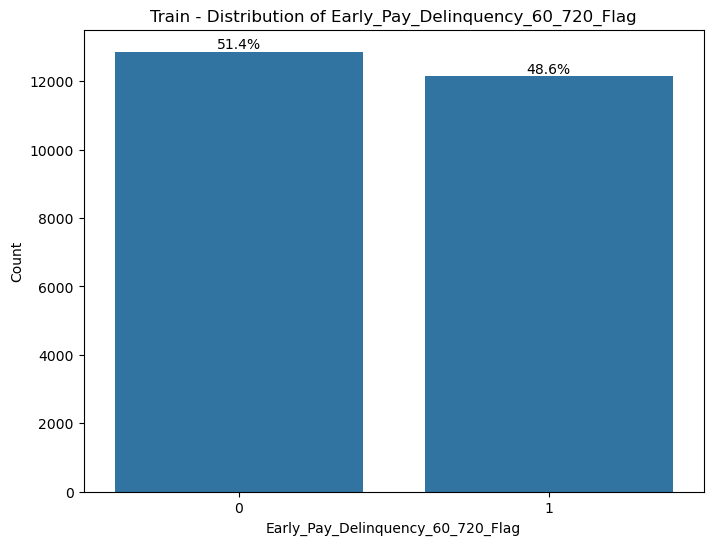

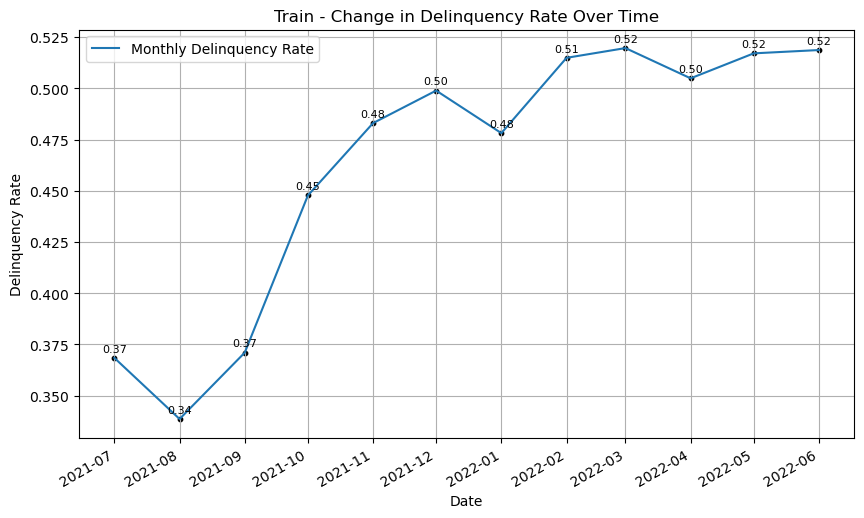

                         **Test**



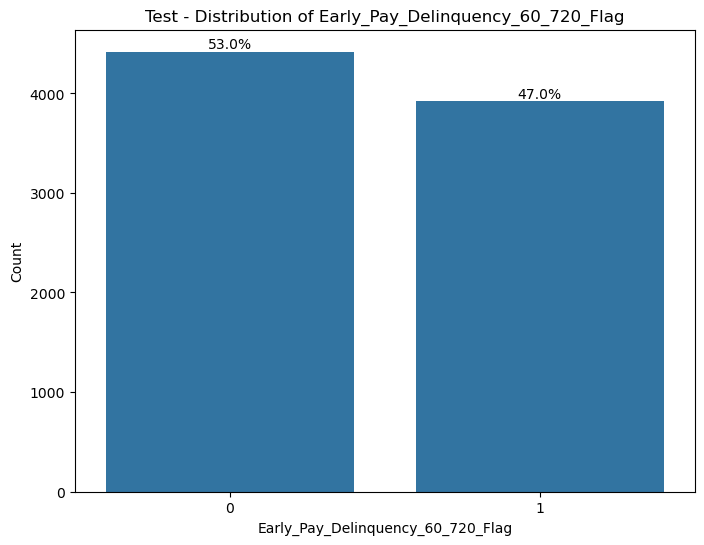

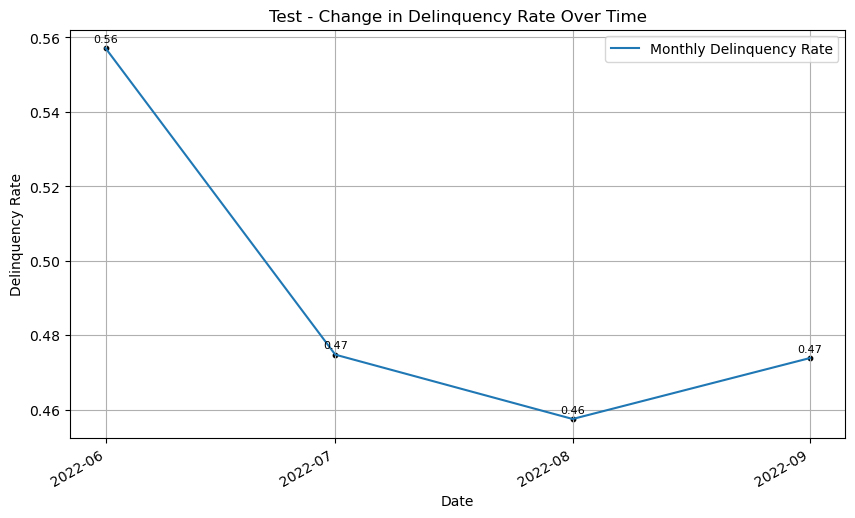

                         **Holdout**



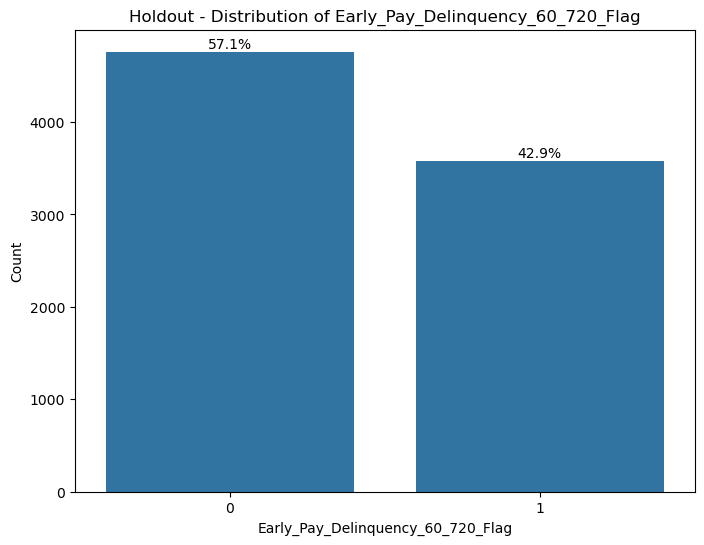

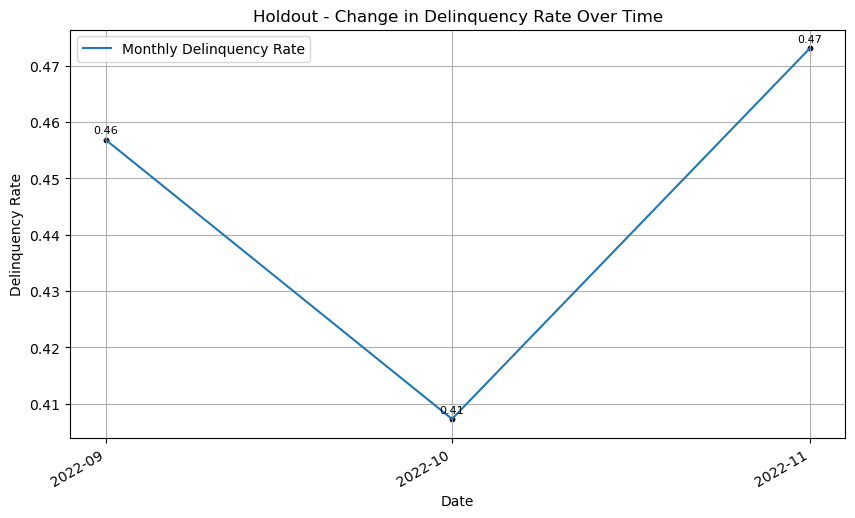

In [35]:
for str_filename, df in dict_df.items(): 
    #get bad rate displayed
    df_bad_rate = get_bad_rate(str_filename,df, date_col, str_target)
    #save in csv
    df_bad_rate.to_csv(f'./output/{str_model}_{str_filename}_delinquency_rate.csv', index=False)

## 4. Feature Distribution

In [36]:
list_cols_model = ['dti__app',
                   'ENG-bk',
                   'inquirybanking12month__ln',
                   'miles_odometer__app',
                   'ENG-loan_to_value',
                   're01s__tu',
                   'int_bad_3mo_open__tu_pmthx',
                   'balmag01__tu',
                   'subjectstabilityindex__ln',
                   'ENG-franchise',
                   'derogseverityindex__ln',
                   'g414s__tu',
                   'g106s__tu',
                   'rp01s__tu',
                   'flt_wtd_avg_open__tu_pmthx',
                   'addrlastmoveecontrajectoryindex__ln',
                   'evictioncount__ln',
                   'flt_wtd_avg_closed__tu_pmthx',
                   'int_bad_3mo_closed__tu_pmthx',
                   'int_bad_6mo_open_end__tu_pmthx']

**Train**

**dti__app**


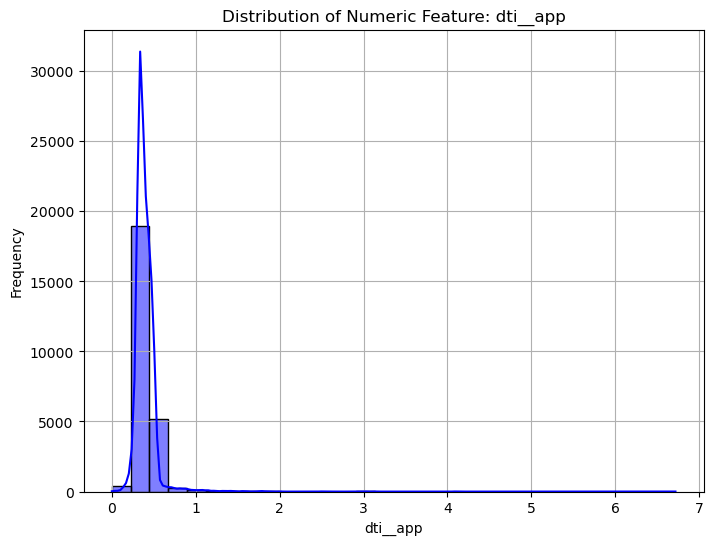

**ENG-bk**


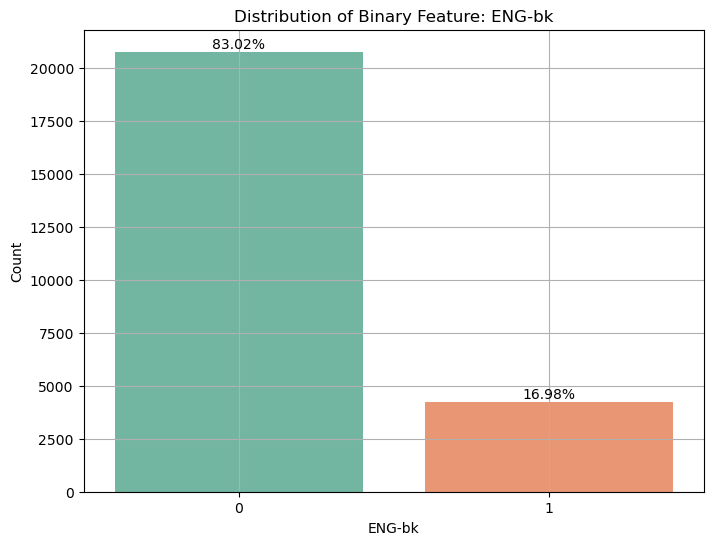

**inquirybanking12month__ln**


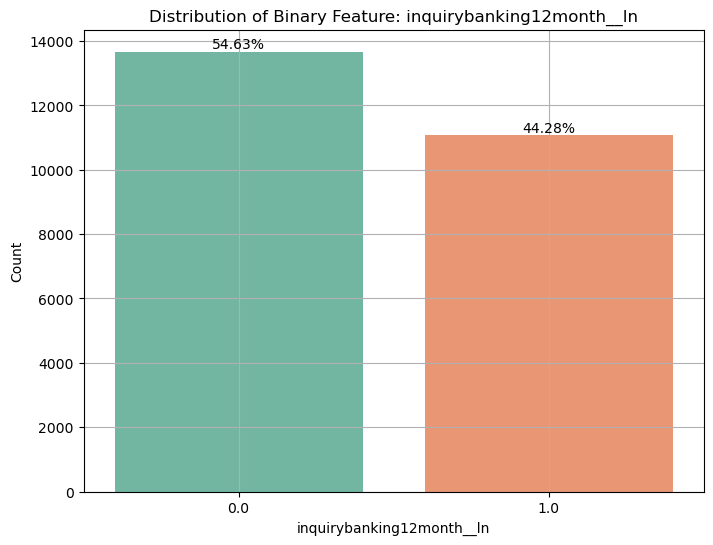

**miles_odometer__app**


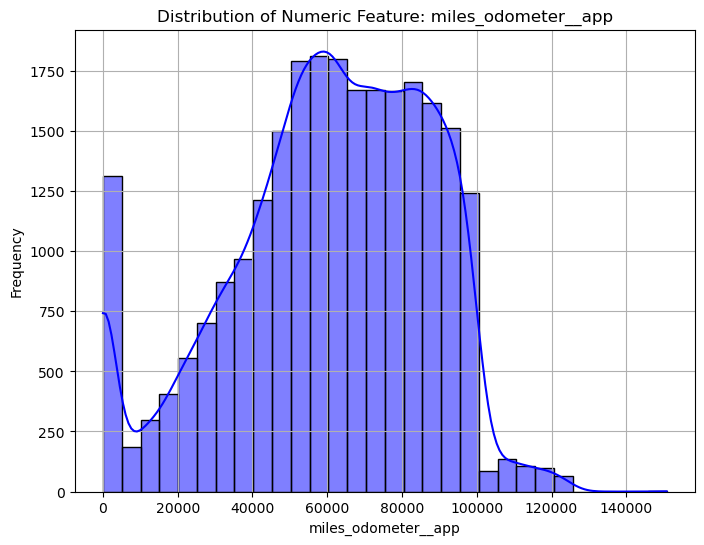

**ENG-loan_to_value**


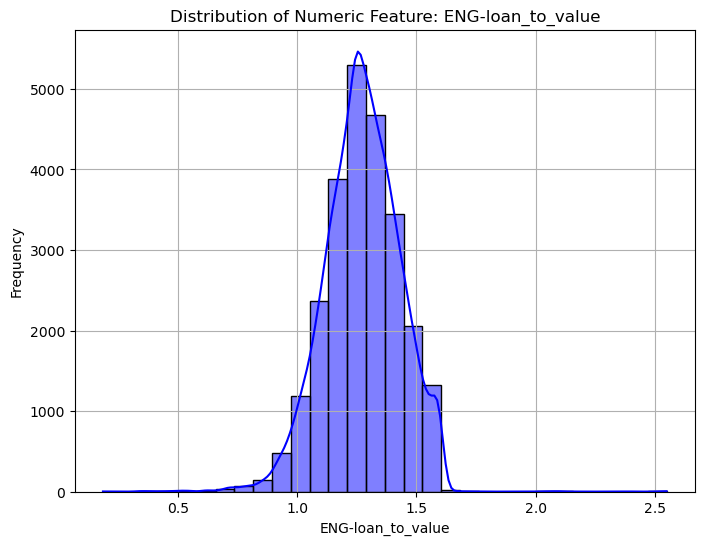

**re01s__tu**


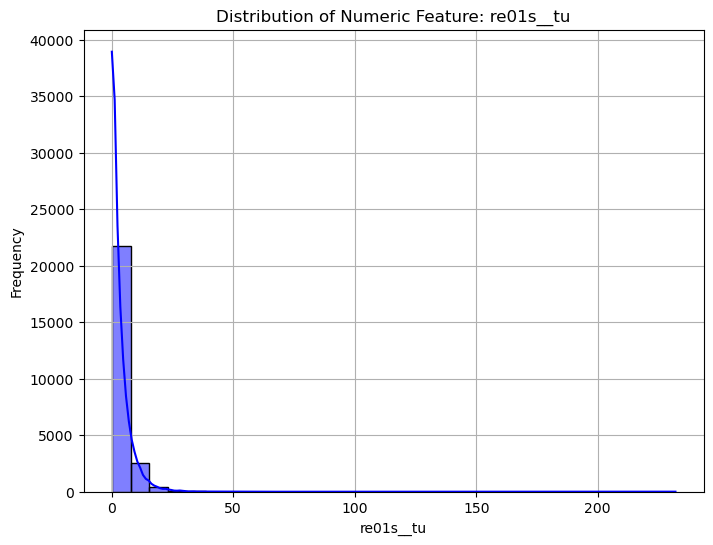

**int_bad_3mo_open__tu_pmthx**


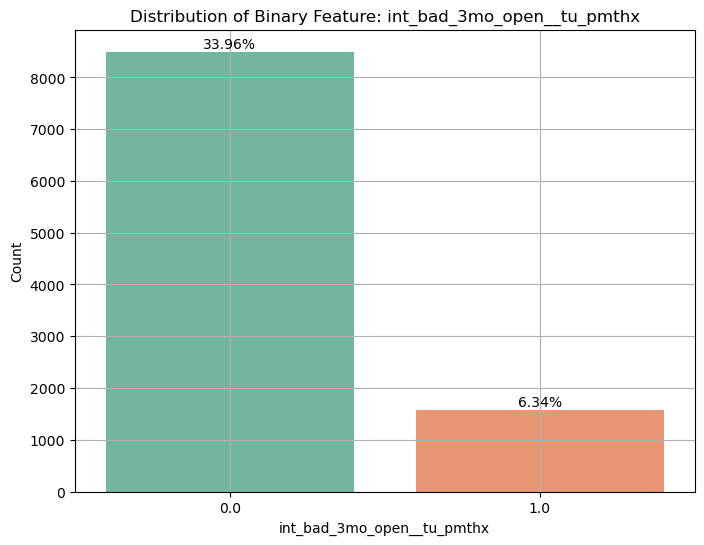

**balmag01__tu**


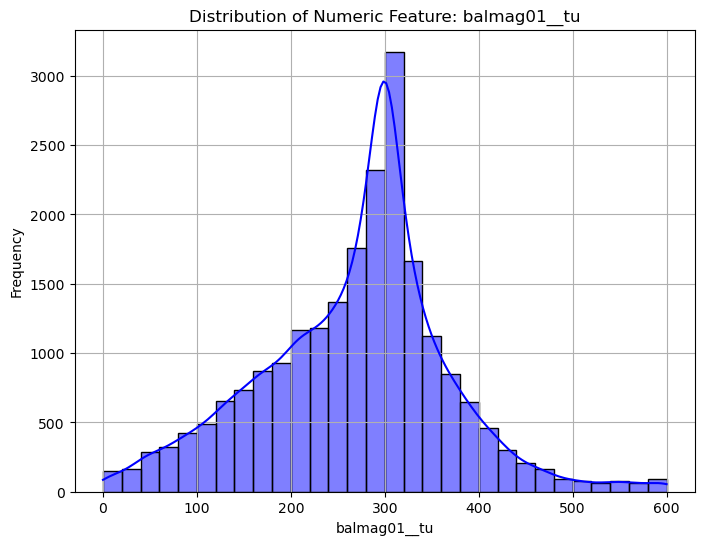

**subjectstabilityindex__ln**


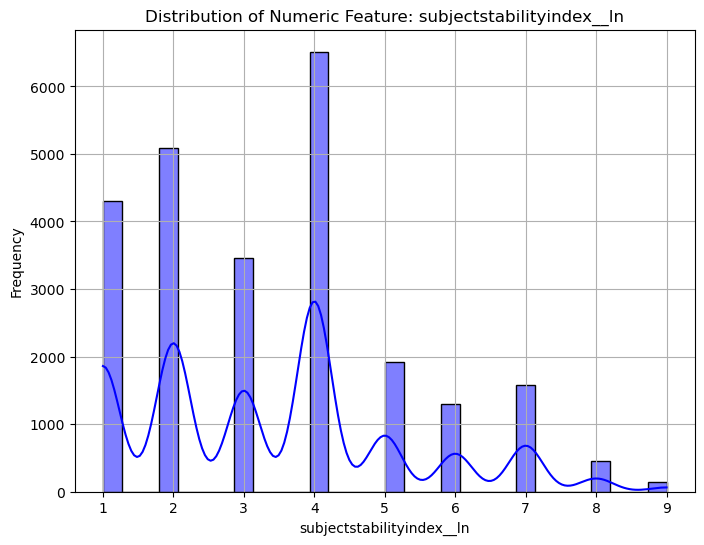

**ENG-franchise**


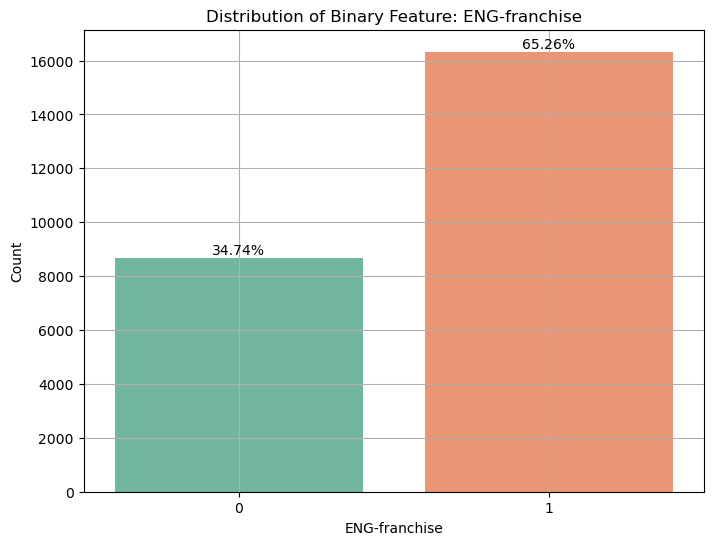

**derogseverityindex__ln**


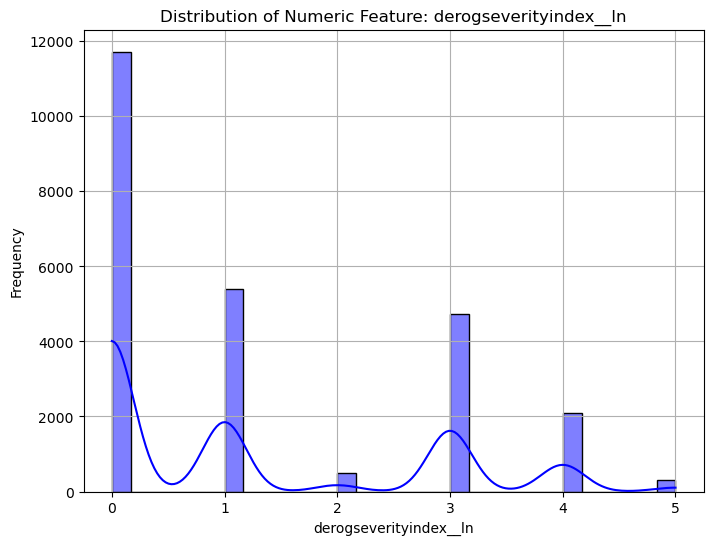

**g414s__tu**


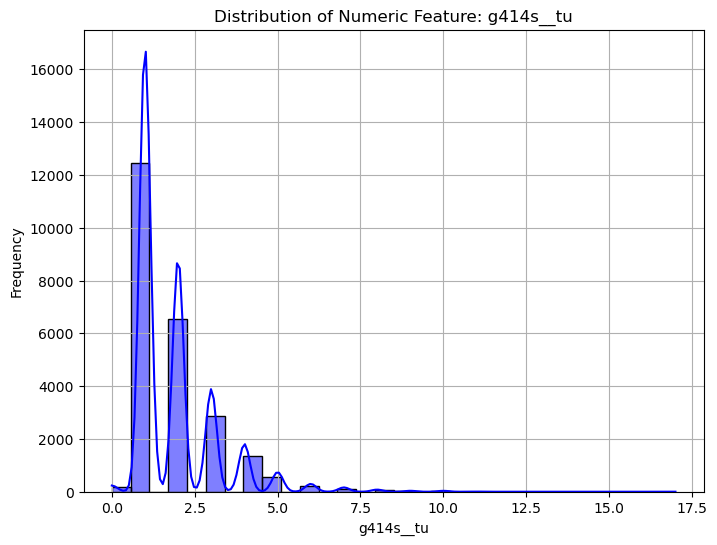

**g106s__tu**


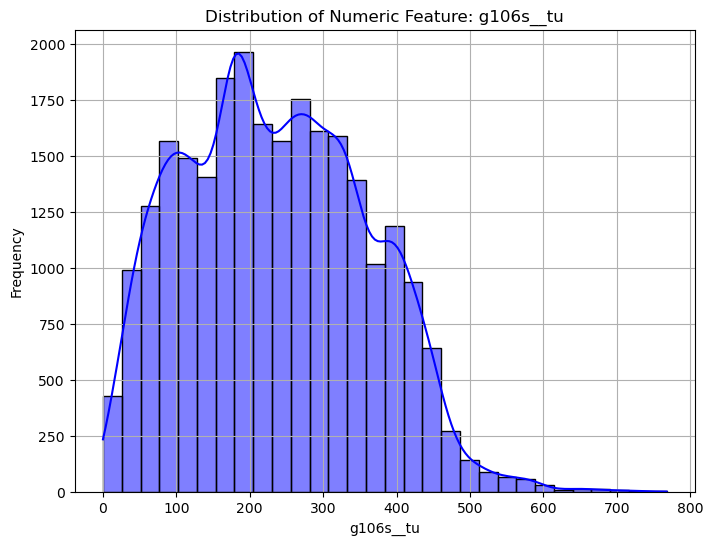

**rp01s__tu**


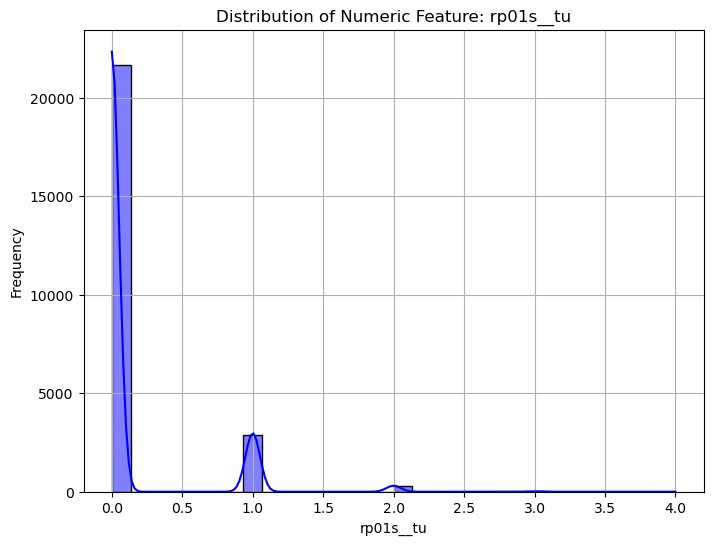

**flt_wtd_avg_open__tu_pmthx**


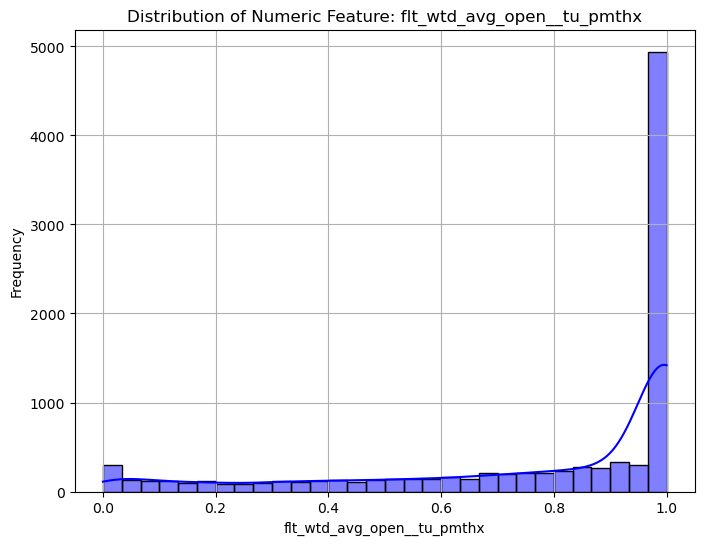

**addrlastmoveecontrajectoryindex__ln**


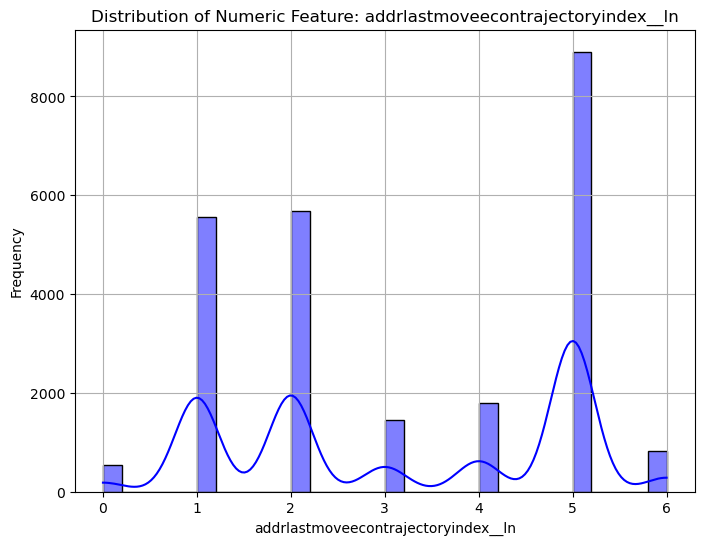

**evictioncount__ln**


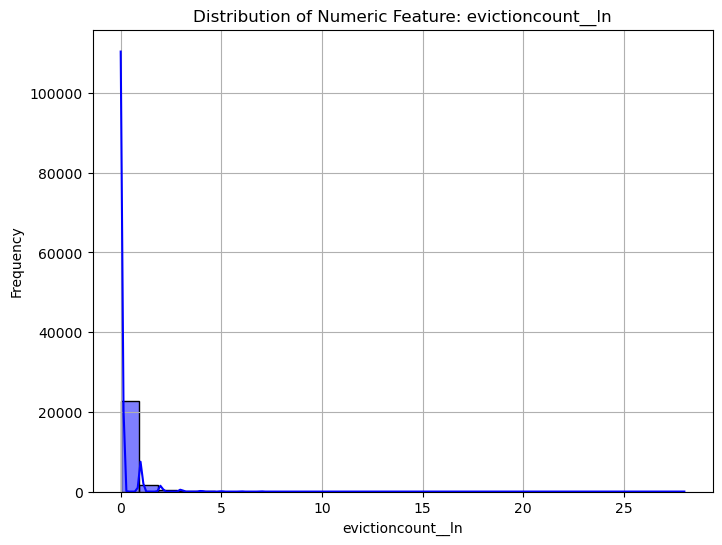

**flt_wtd_avg_closed__tu_pmthx**


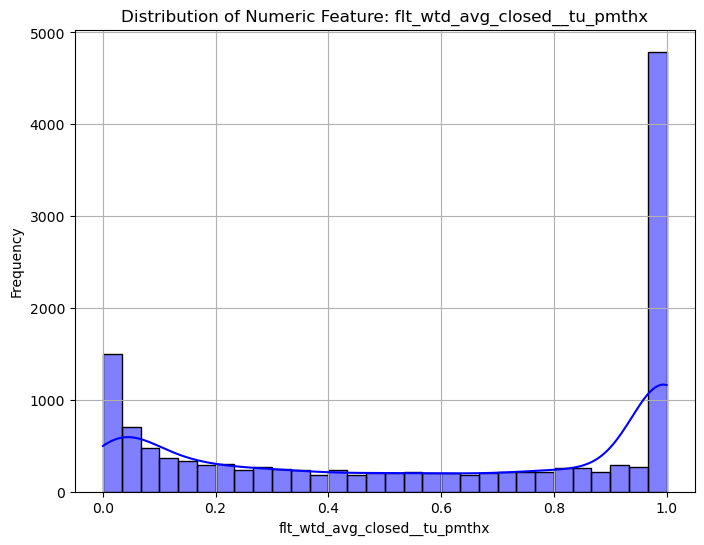

**int_bad_3mo_closed__tu_pmthx**


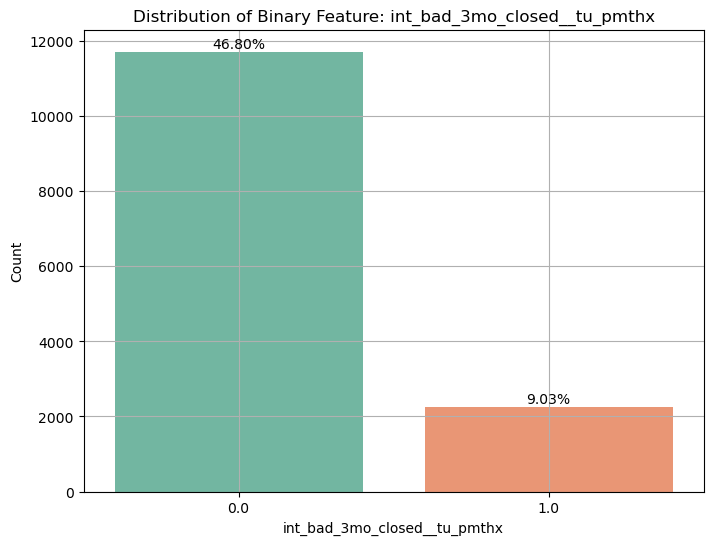

**int_bad_6mo_open_end__tu_pmthx**


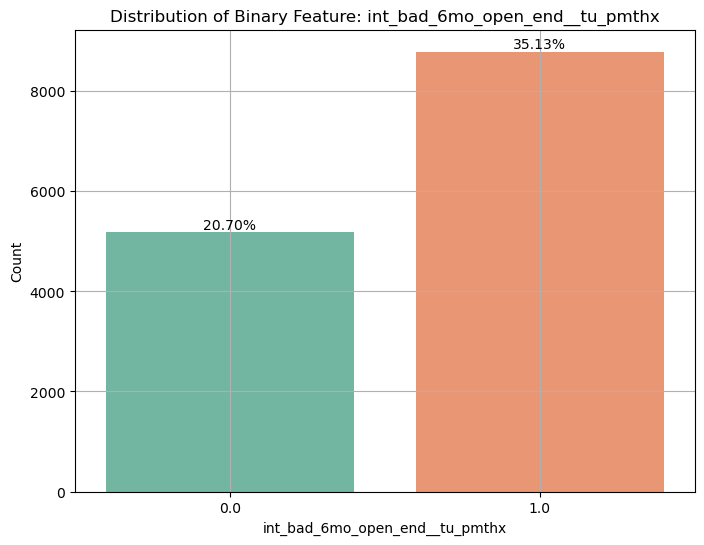

In [37]:
plot_feat_distribution('Train', Train, df_explained, list_cols_model)

**Test**

**dti__app**


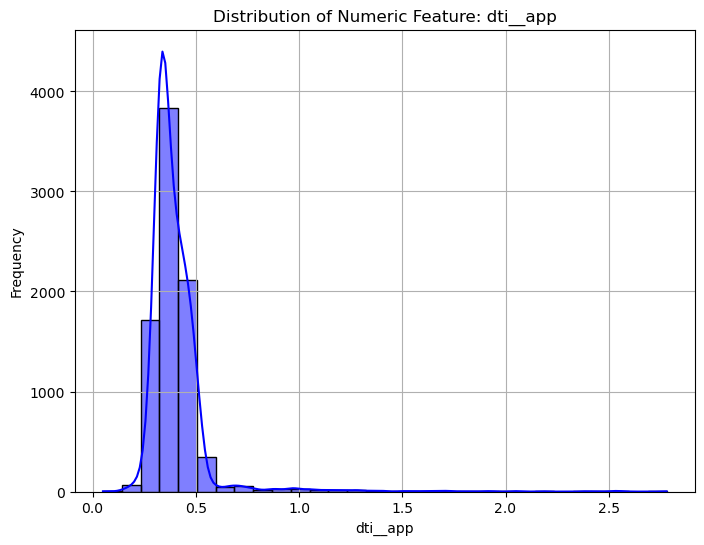

**ENG-bk**


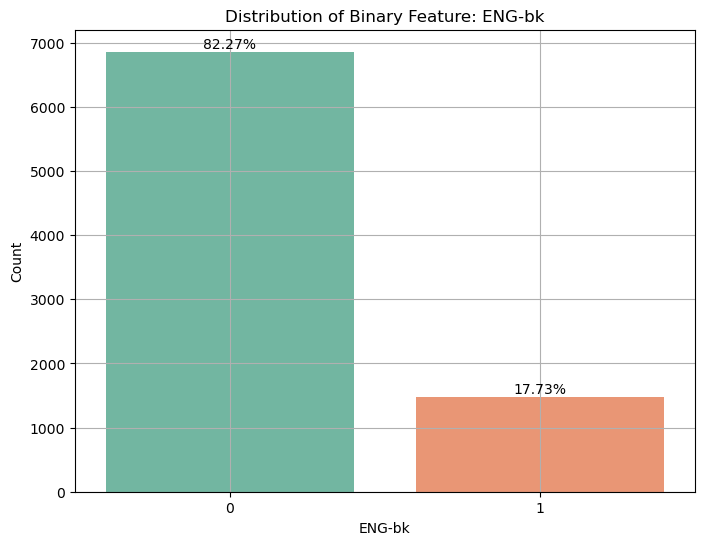

**inquirybanking12month__ln**


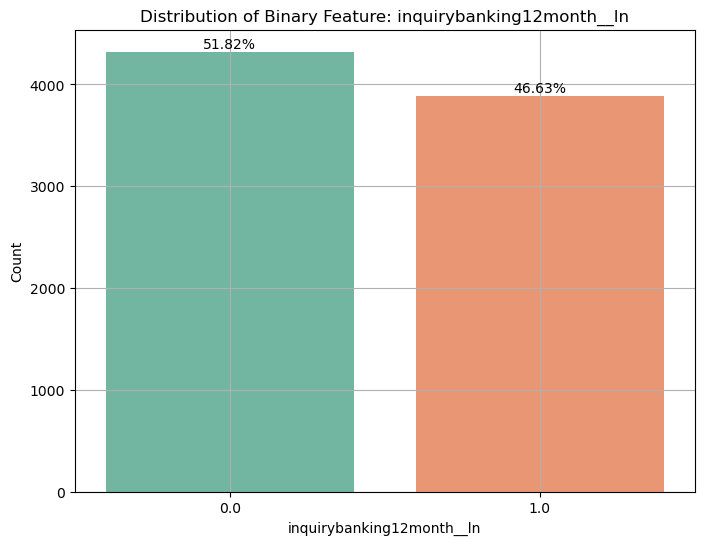

**miles_odometer__app**


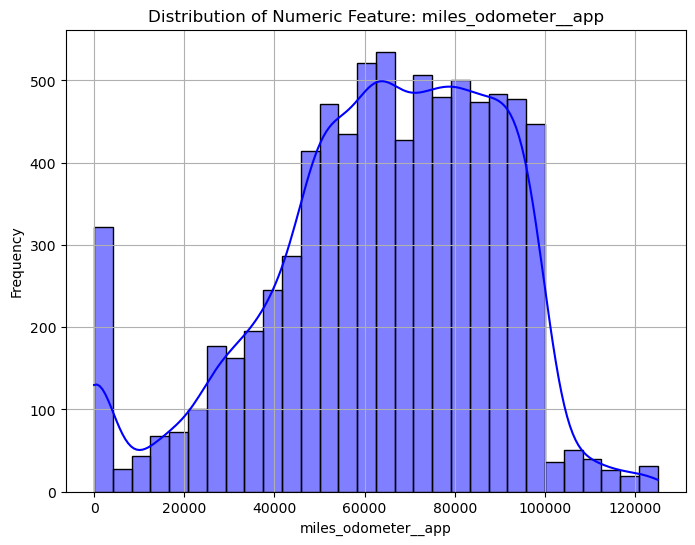

**ENG-loan_to_value**


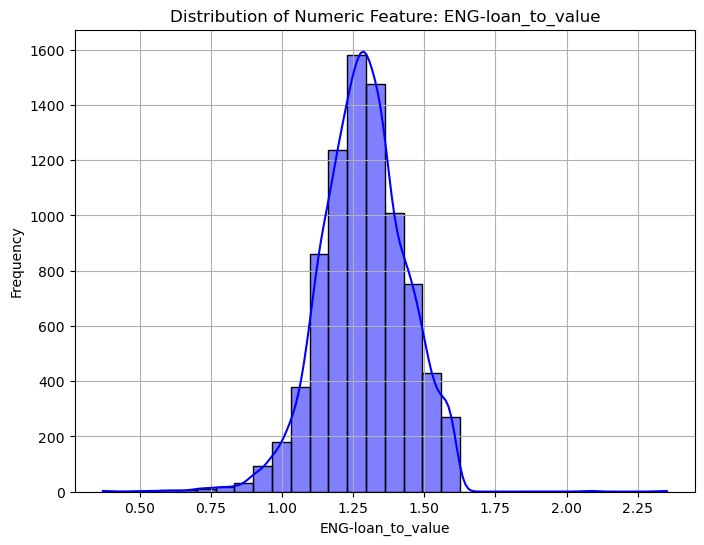

**re01s__tu**


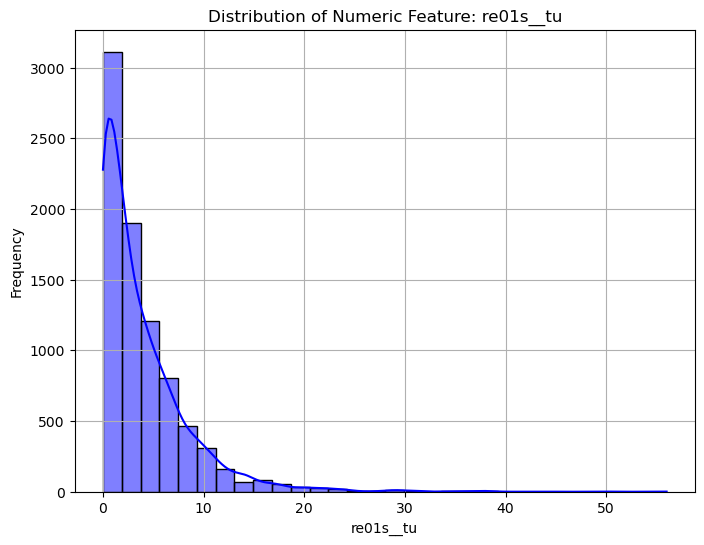

**int_bad_3mo_open__tu_pmthx**


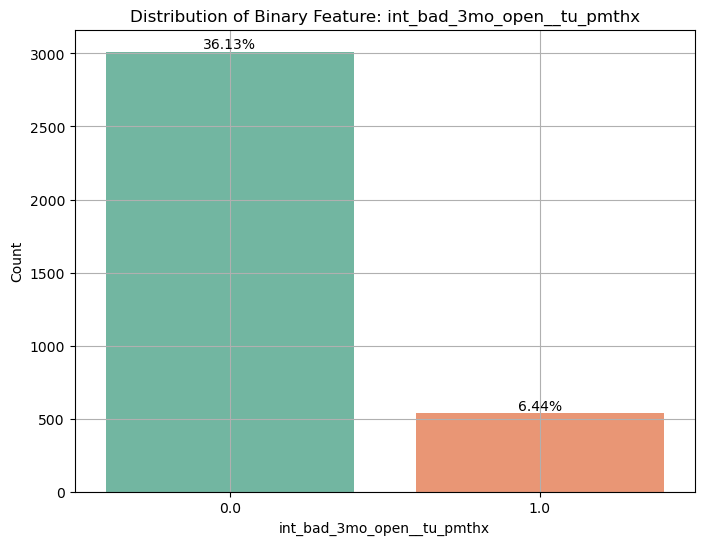

**balmag01__tu**


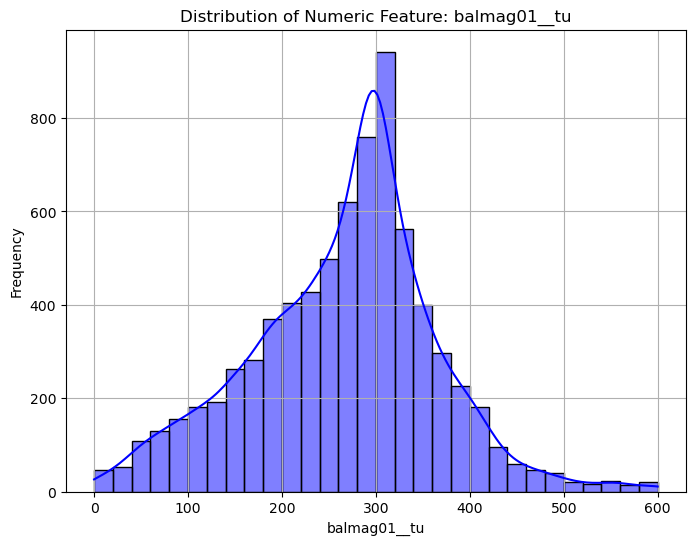

**subjectstabilityindex__ln**


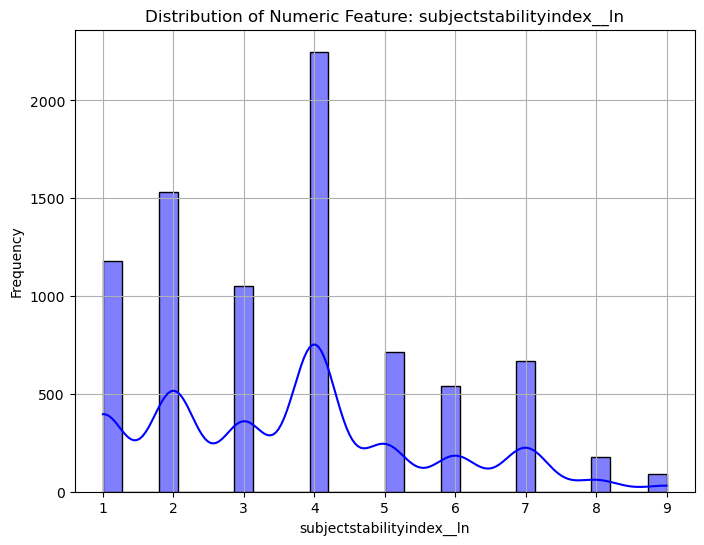

**ENG-franchise**


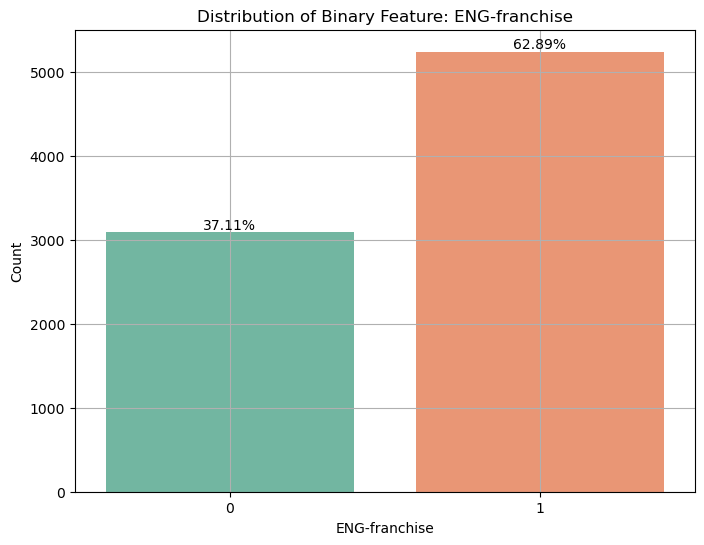

**derogseverityindex__ln**


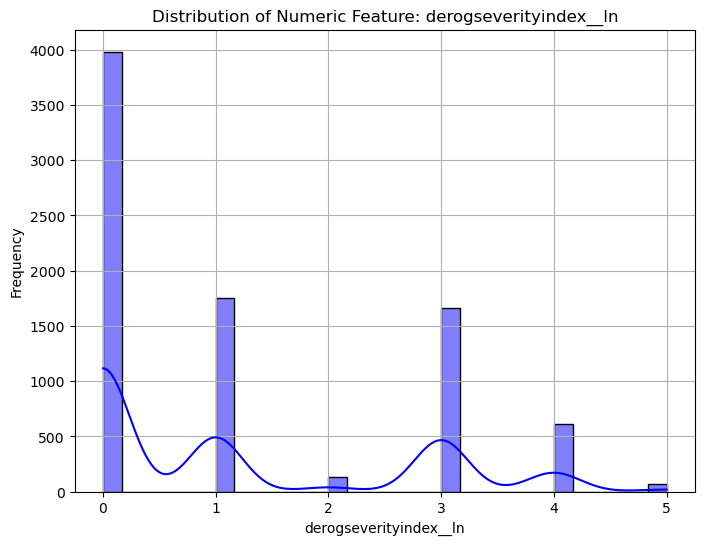

**g414s__tu**


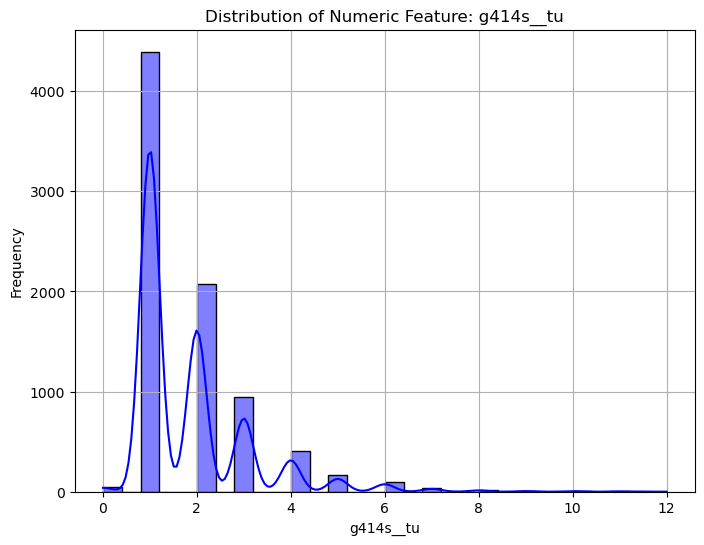

**g106s__tu**


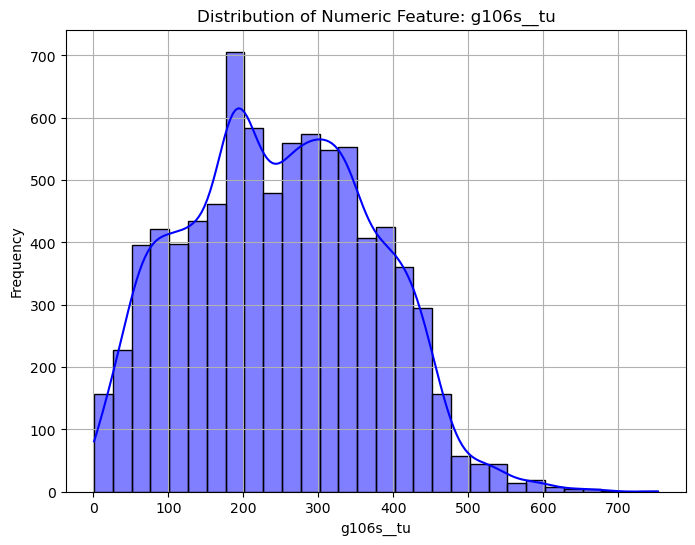

**rp01s__tu**


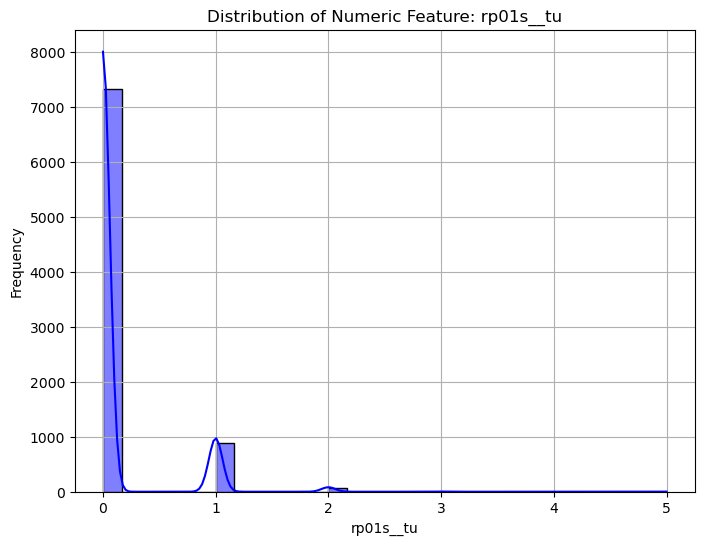

**flt_wtd_avg_open__tu_pmthx**


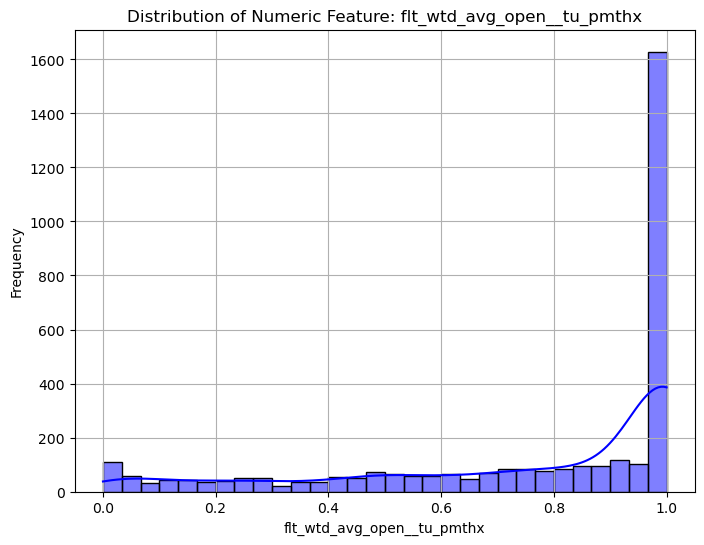

**addrlastmoveecontrajectoryindex__ln**


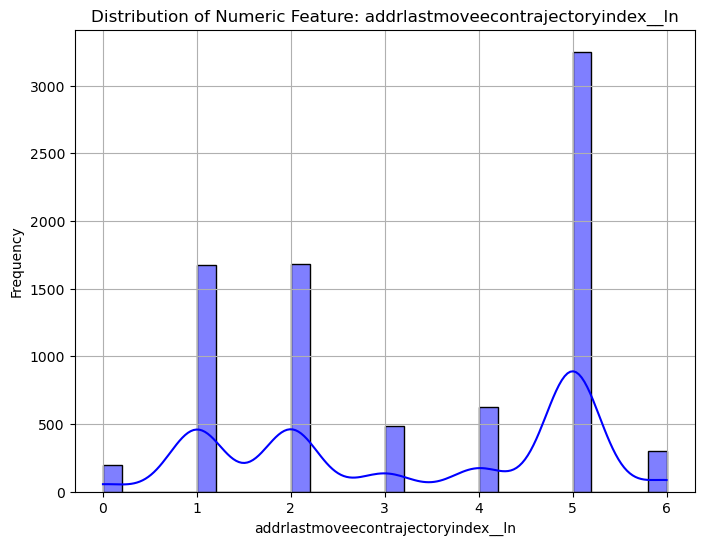

**evictioncount__ln**


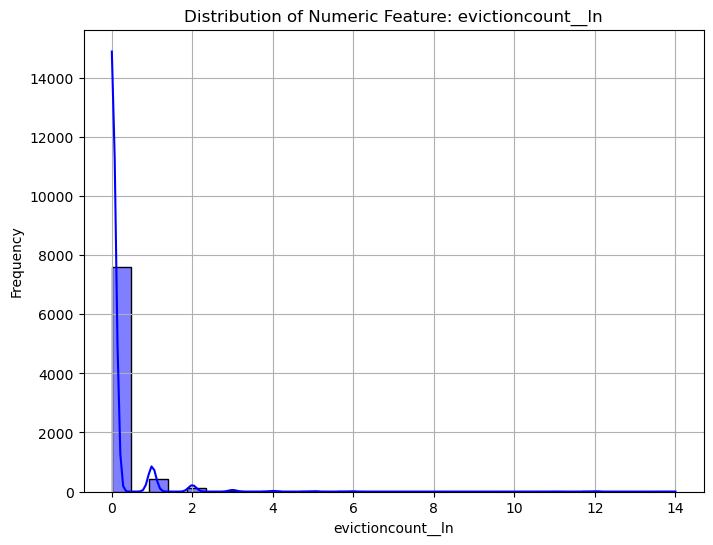

**flt_wtd_avg_closed__tu_pmthx**


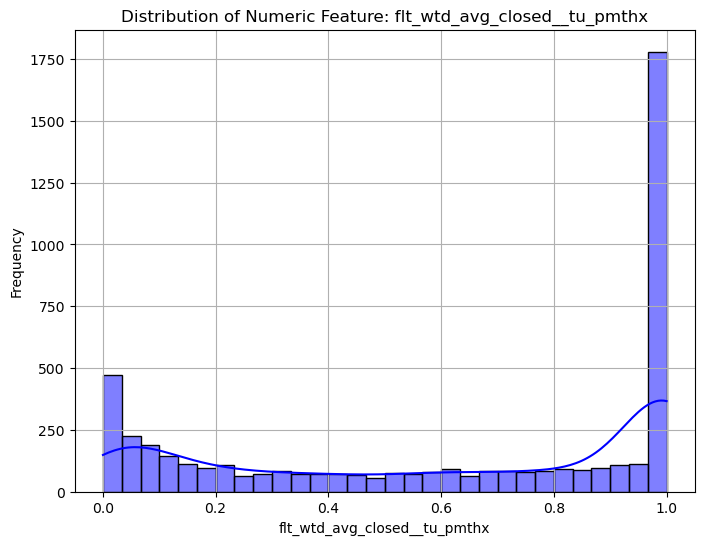

**int_bad_3mo_closed__tu_pmthx**


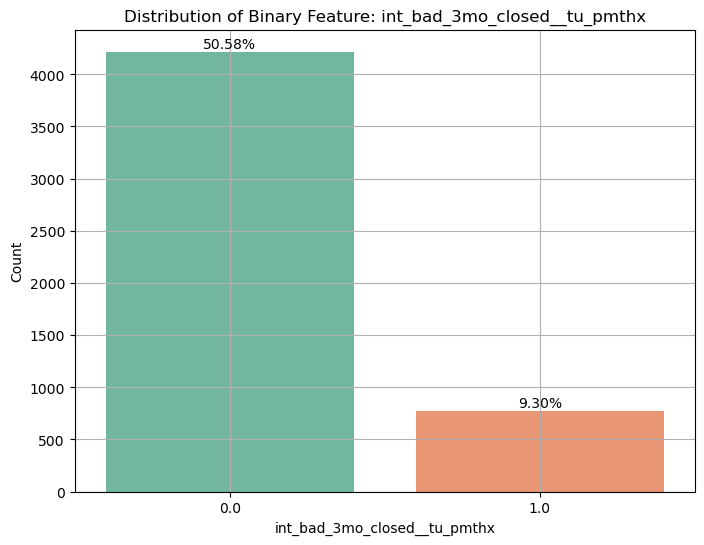

**int_bad_6mo_open_end__tu_pmthx**


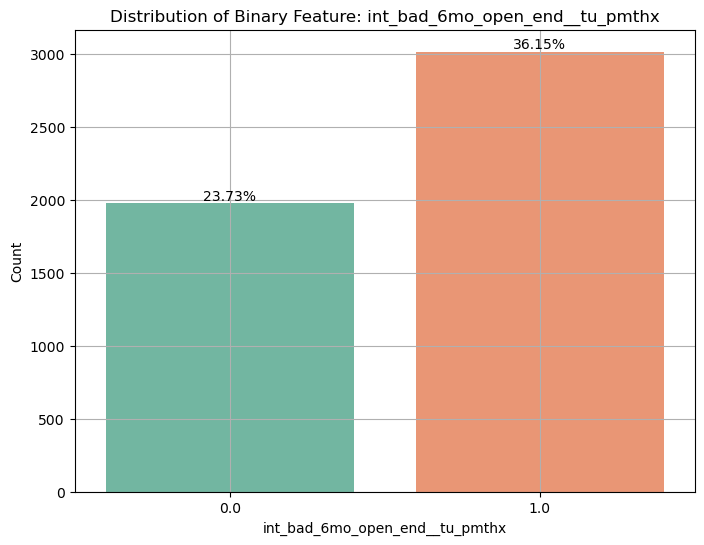

In [38]:
plot_feat_distribution('Test', Test, df_explained, list_cols_model)

# Diret Model

In [39]:
#pull data
dict_df={}
for str_filename in list_str_filename:
    key_filename = str_filename.split('.')[0]
    str_uri = f's3://{str_project}/13_60_in_720_dl/01_data_split/{str_filename}'
    df = pd.read_parquet(str_uri)
    dict_df[key_filename] = df

## 1. Row/Column

In [40]:
for str_filename, df in dict_df.items():
    print(f"{str_filename} Shape: {df.shape}")

df_train Shape: (25018, 2777)
df_test Shape: (8340, 2777)
df_holdout Shape: (8340, 2777)


In [41]:
#Train = pd.concat([dict_df['df_train'], dict_df['df_valid']], ignore_index=True)
Train = dict_df['df_train']
print(f'Train Data Shape: {Train.shape}')
Test = dict_df['df_test']
print(f'Test Data Shape: {Test.shape}')
Holdout = dict_df['df_holdout']
print(f'Holdout Data Shape: {Holdout.shape}')
#data save
del dict_df
#new dict_df
dict_df = {'Train': Train,
          'Test': Test,
          'Holdout':Holdout}

Train Data Shape: (25018, 2777)
Test Data Shape: (8340, 2777)
Holdout Data Shape: (8340, 2777)


## 2. Date Range

In [42]:
#clean date col
for str_filename, df in dict_df.items():
    df = clean_date_columns(df,[date_col])
    #get min/max date
    min_date = df[date_col].min().strftime('%Y-%m-%d')
    max_date = df[date_col].max().strftime('%Y-%m-%d')
    print(f"Date range for {str_filename}: {min_date} to {max_date}")

Date range for Train: 2021-07-26 to 2022-06-30
Date range for Test: 2022-06-30 to 2022-09-22
Date range for Holdout: 2022-09-22 to 2022-11-30


## 3. Delinquency Rate

In [43]:
str_model = 'direct'
str_target = 'Early_Pay_Delinquency_60_720_Flag'##note that this target has same name but filtered to only positive net charge

                         **Train**



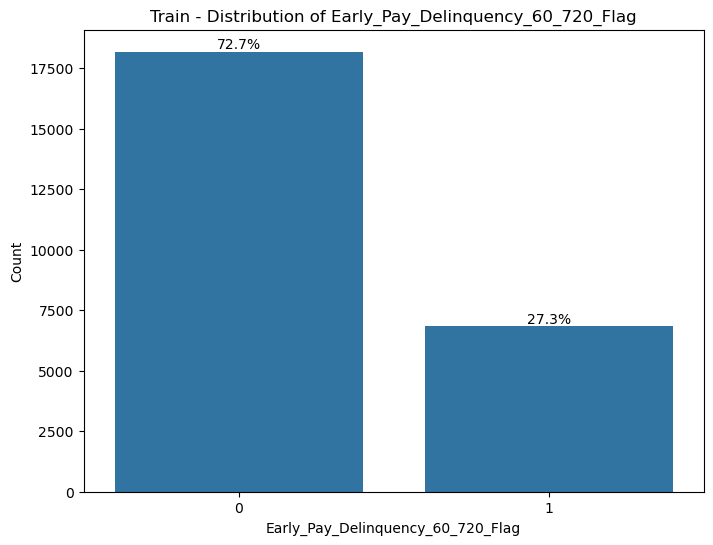

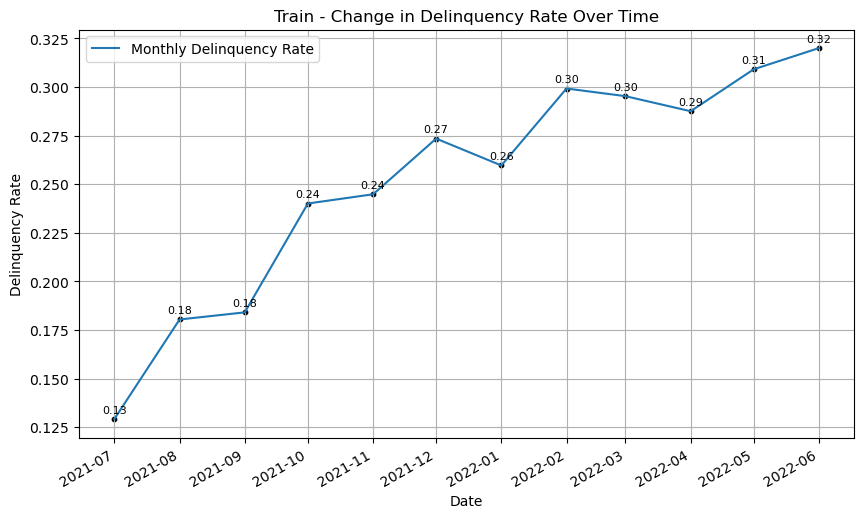

                         **Test**



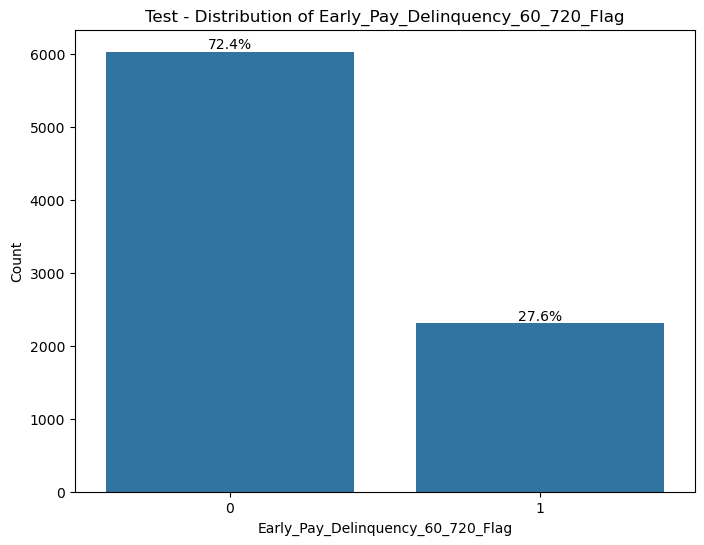

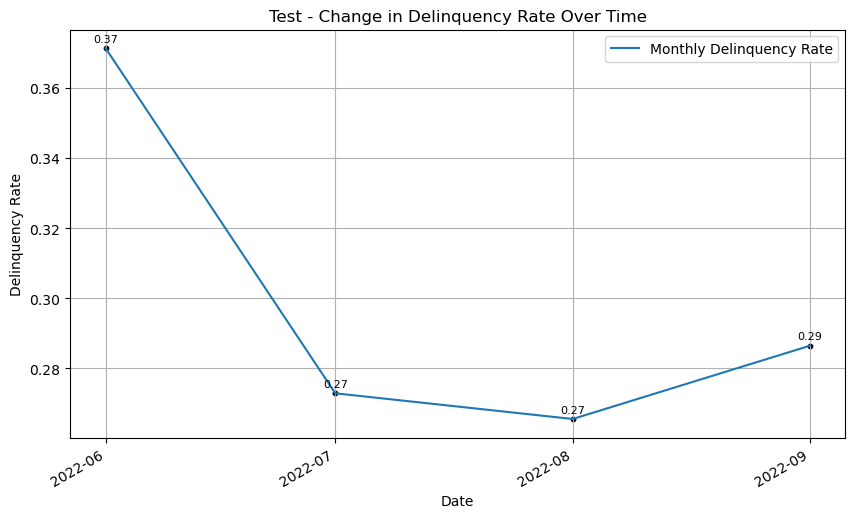

                         **Holdout**



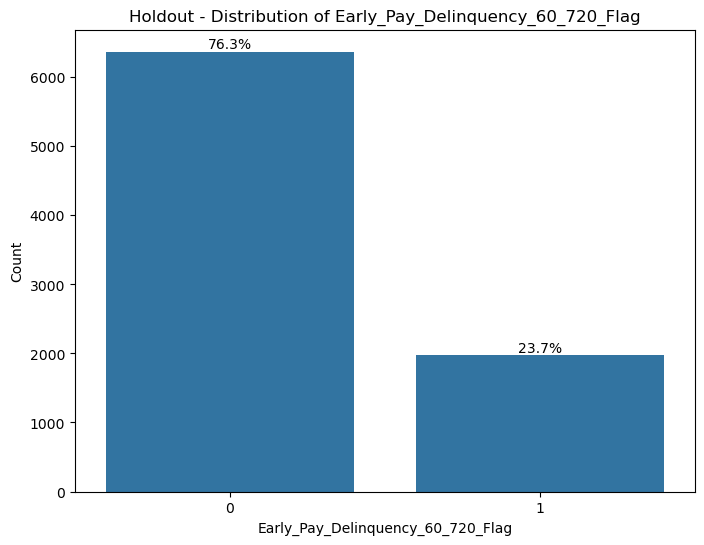

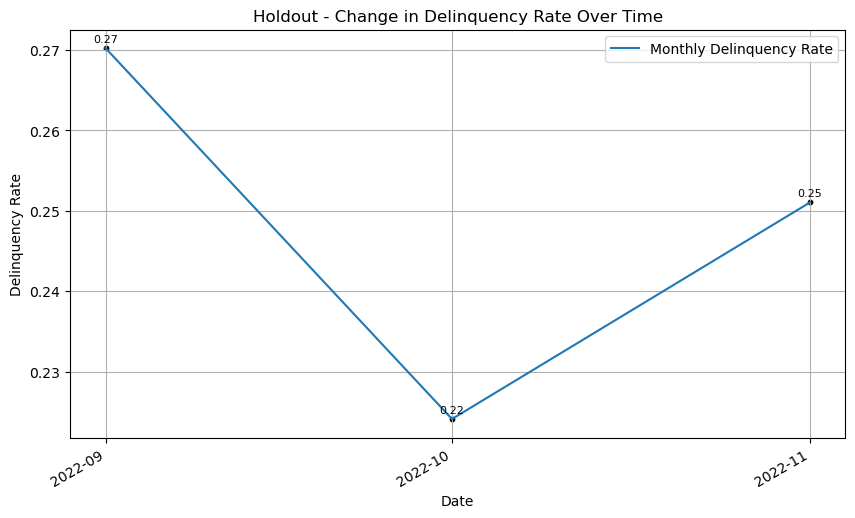

In [44]:
for str_filename, df in dict_df.items(): 
    #get bad rate displayed
    df_bad_rate = get_bad_rate(str_filename,df, date_col, str_target)
    #save in csv
    df_bad_rate.to_csv(f'./output/{str_model}_{str_filename}_delinquency_rate.csv', index=False)

## 4. Feature Distribution

**Train**

**dti__app**


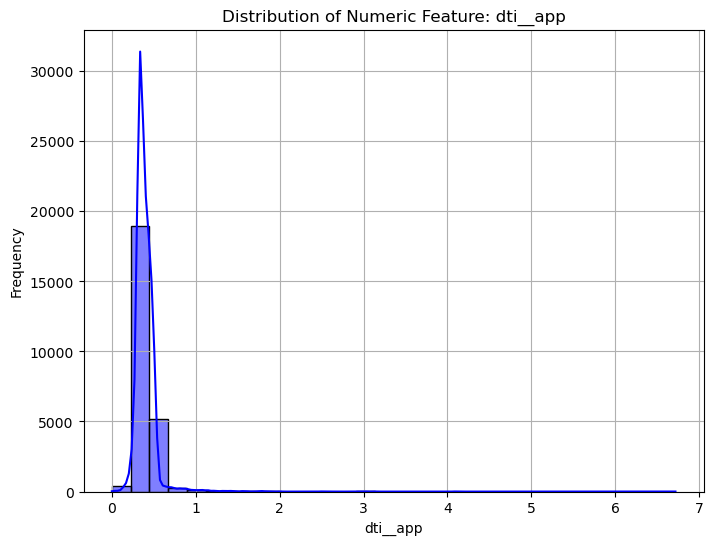

**ENG-bk**


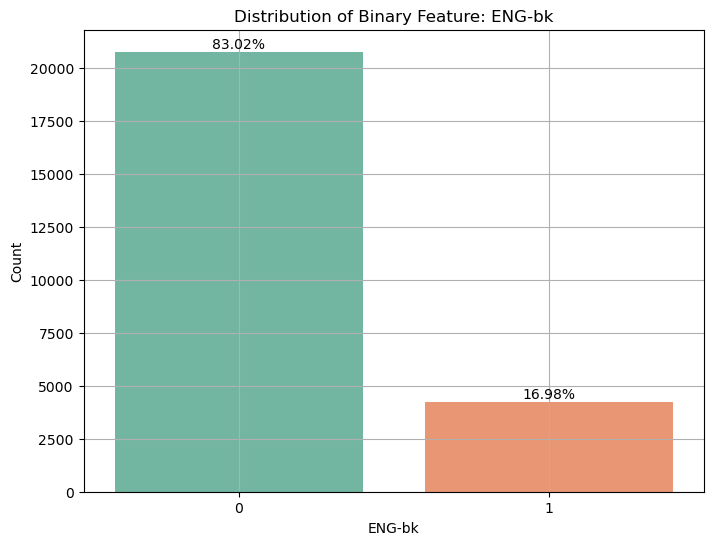

**inquirybanking12month__ln**


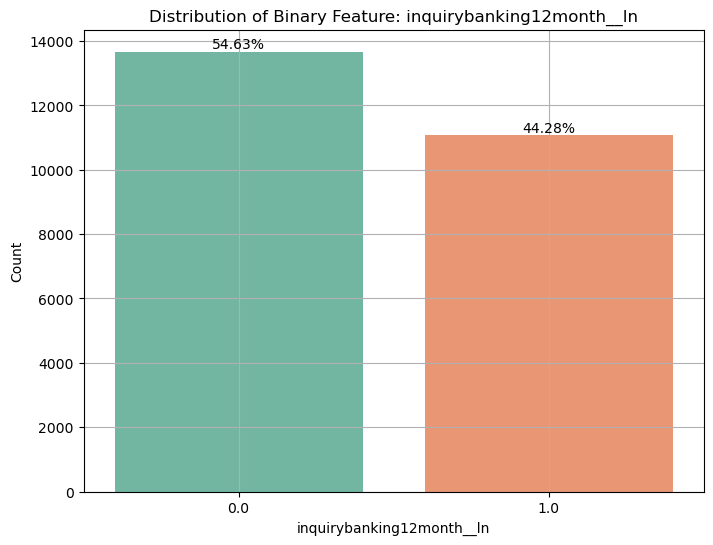

**miles_odometer__app**


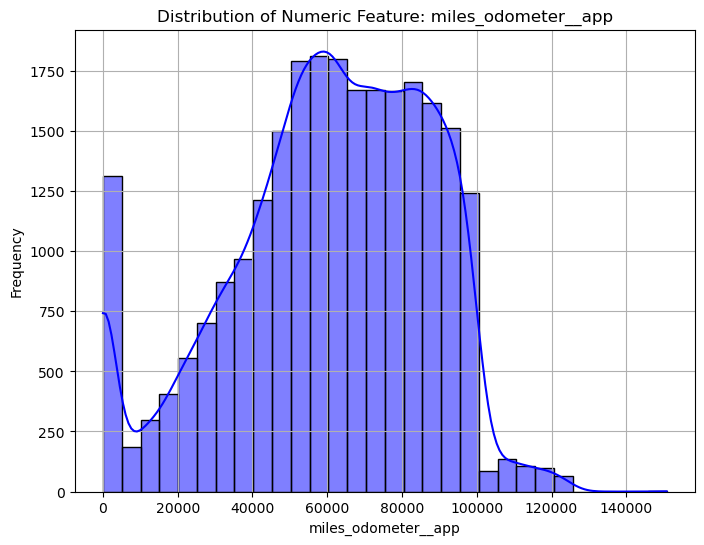

**ENG-loan_to_value**


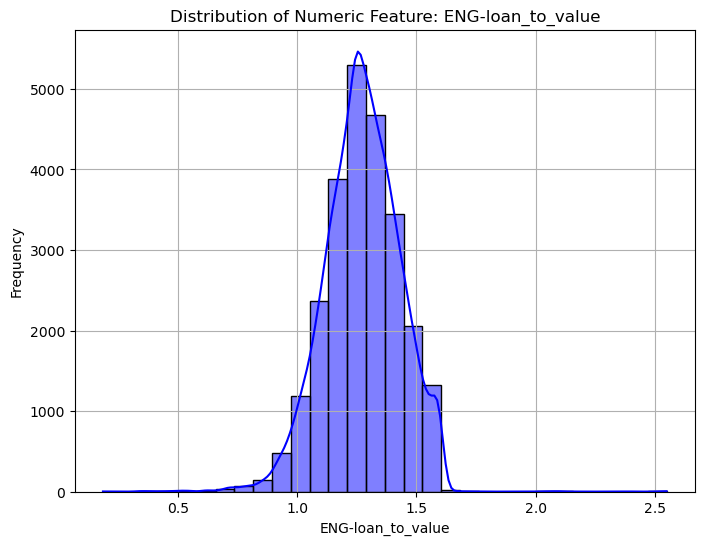

**re01s__tu**


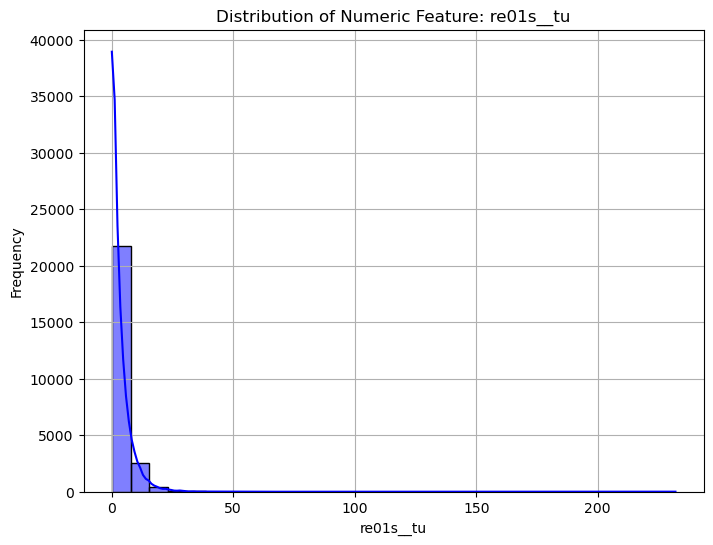

**int_bad_3mo_open__tu_pmthx**


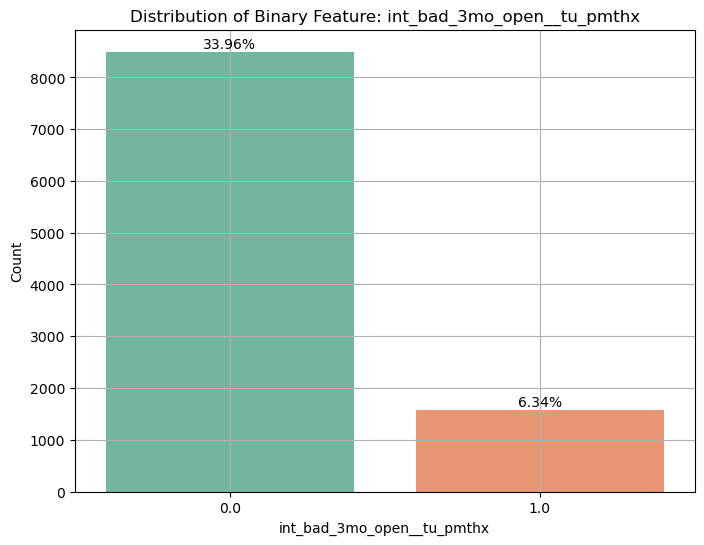

**balmag01__tu**


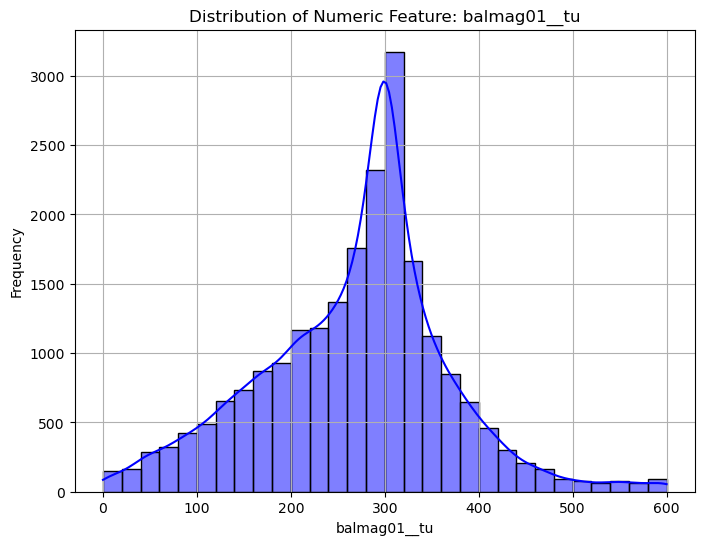

**subjectstabilityindex__ln**


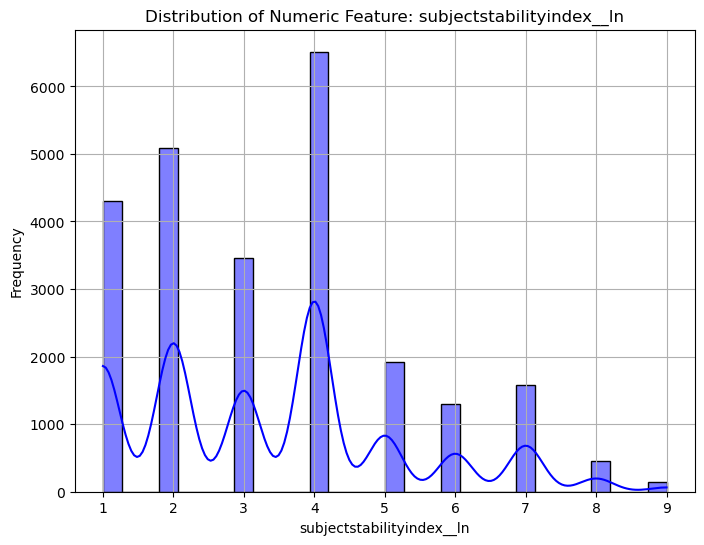

**ENG-franchise**


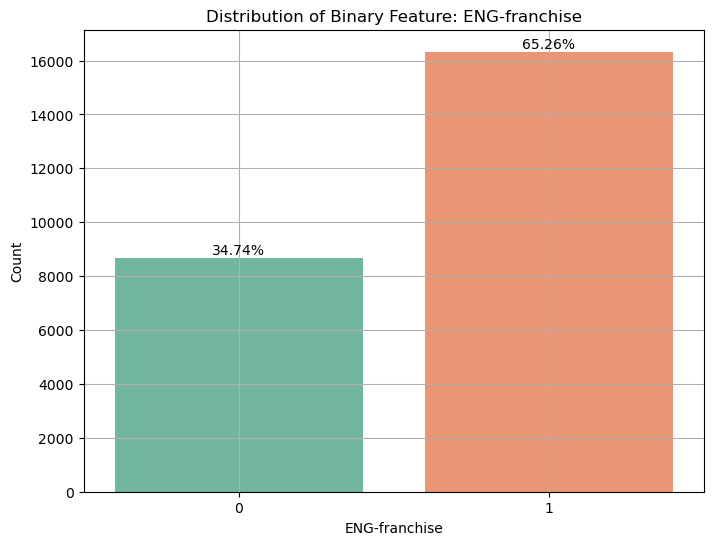

**derogseverityindex__ln**


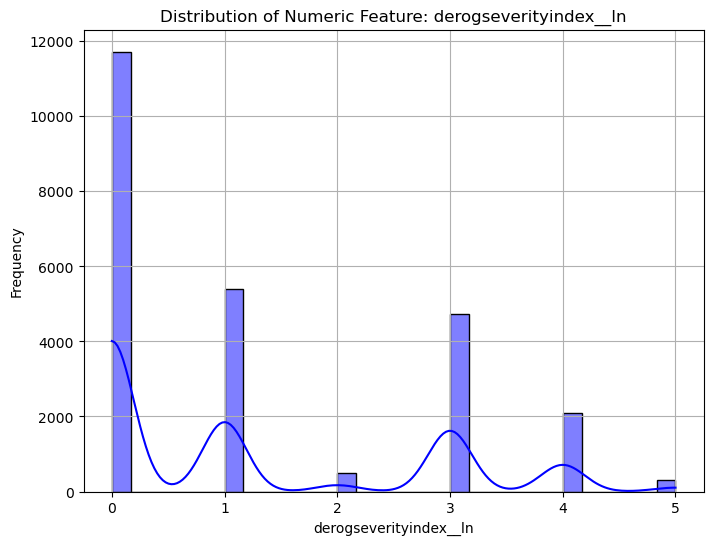

**g414s__tu**


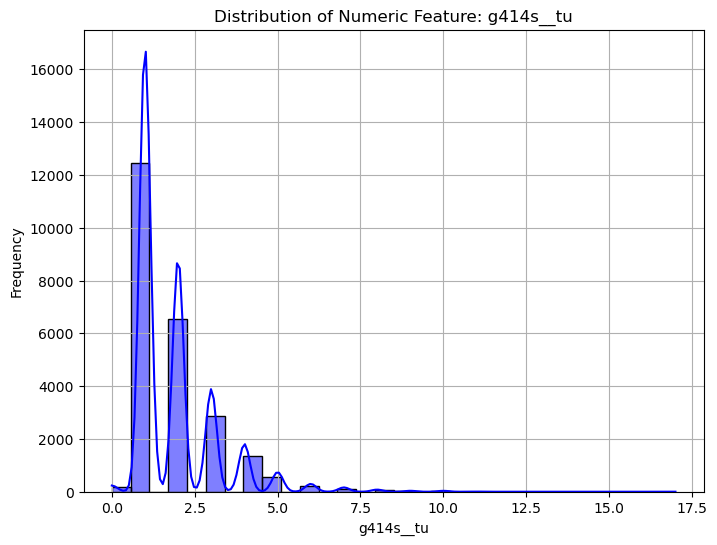

**g106s__tu**


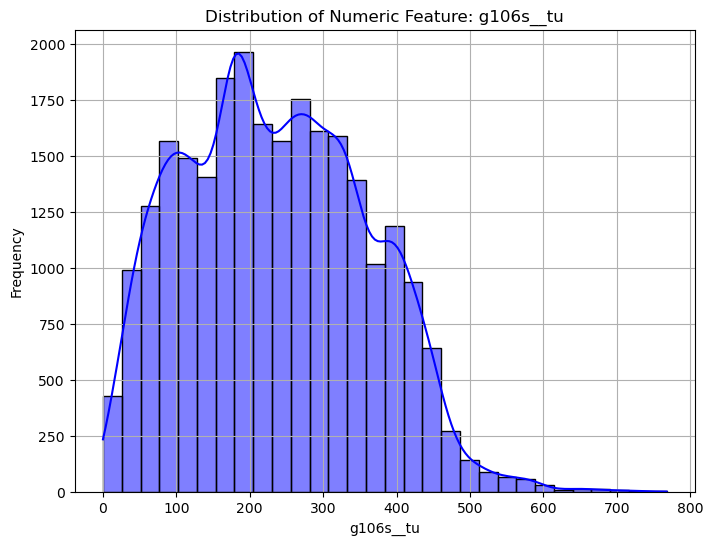

**rp01s__tu**


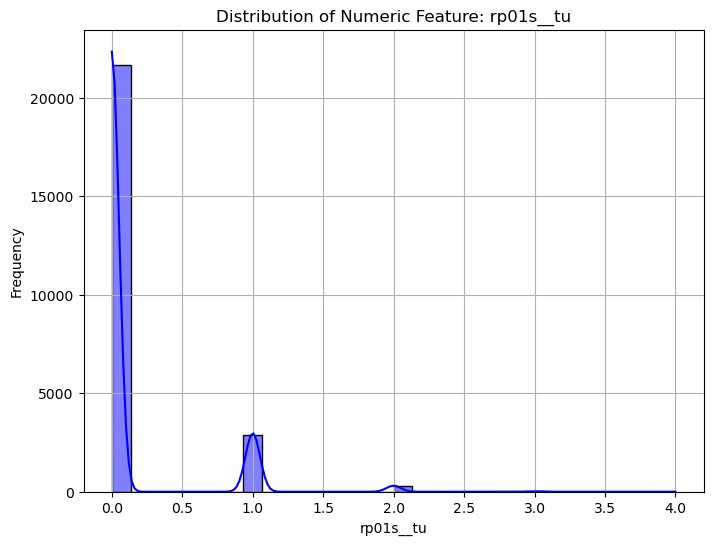

**flt_wtd_avg_open__tu_pmthx**


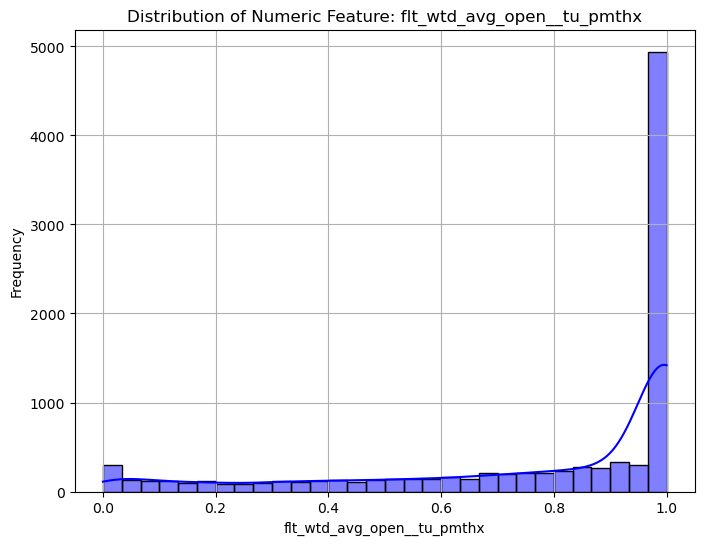

**addrlastmoveecontrajectoryindex__ln**


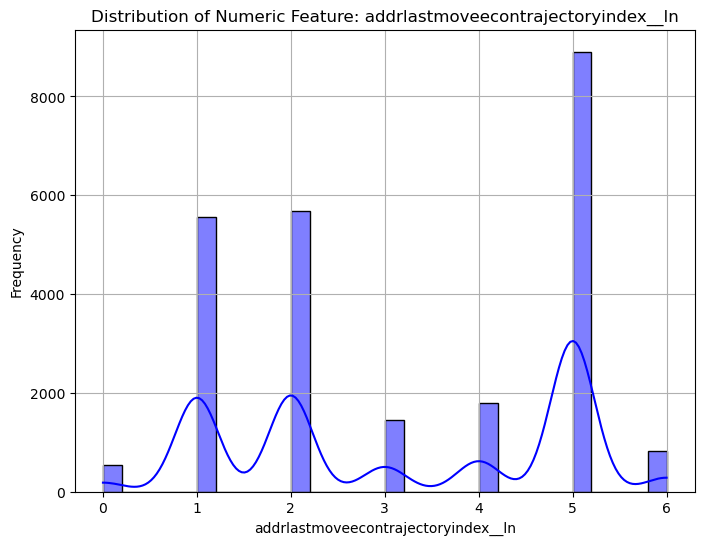

**evictioncount__ln**


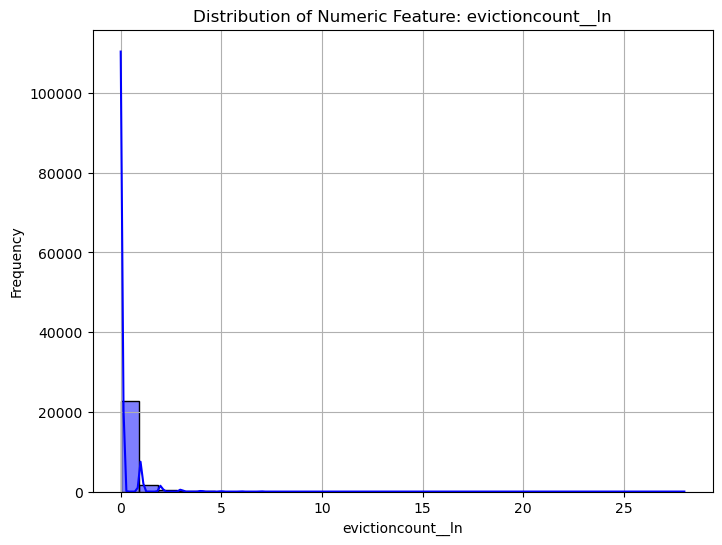

**flt_wtd_avg_closed__tu_pmthx**


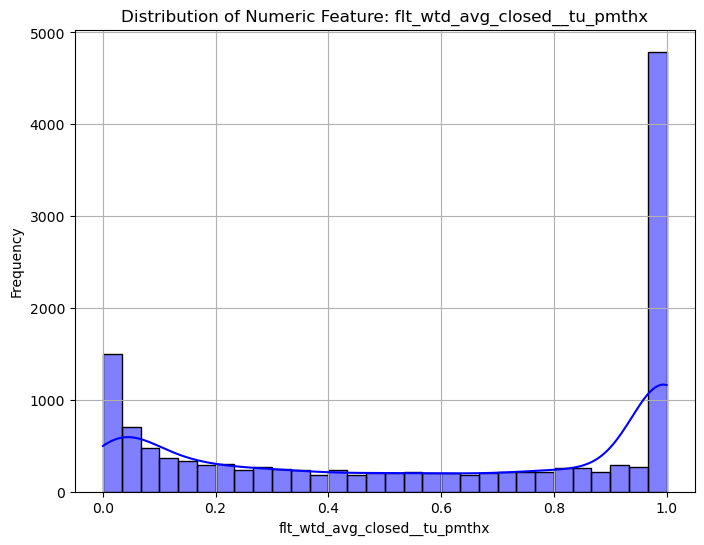

**int_bad_3mo_closed__tu_pmthx**


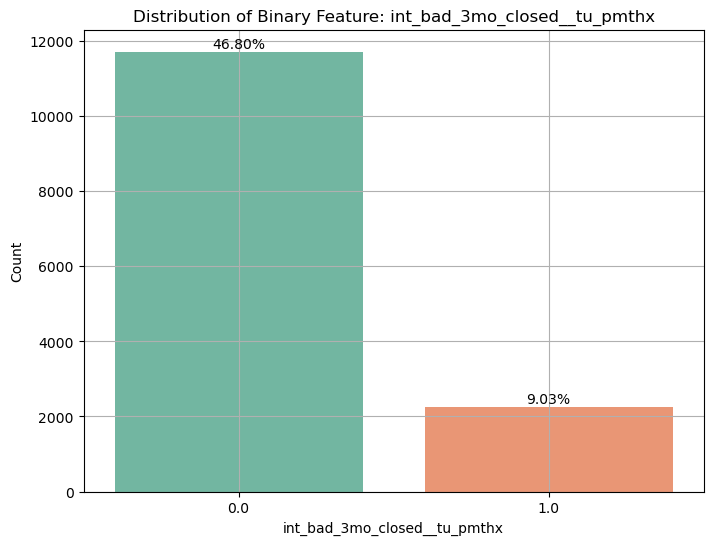

**int_bad_6mo_open_end__tu_pmthx**


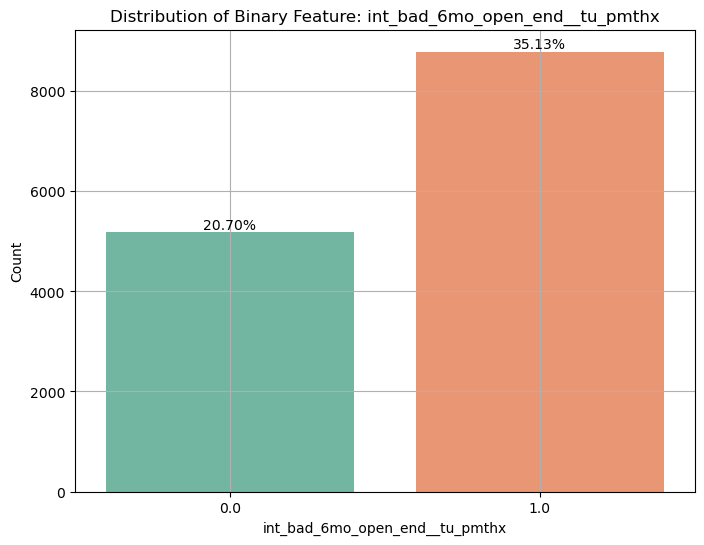

In [45]:
plot_feat_distribution('Train', Train, df_explained, list_cols_model)

**Test**

**dti__app**


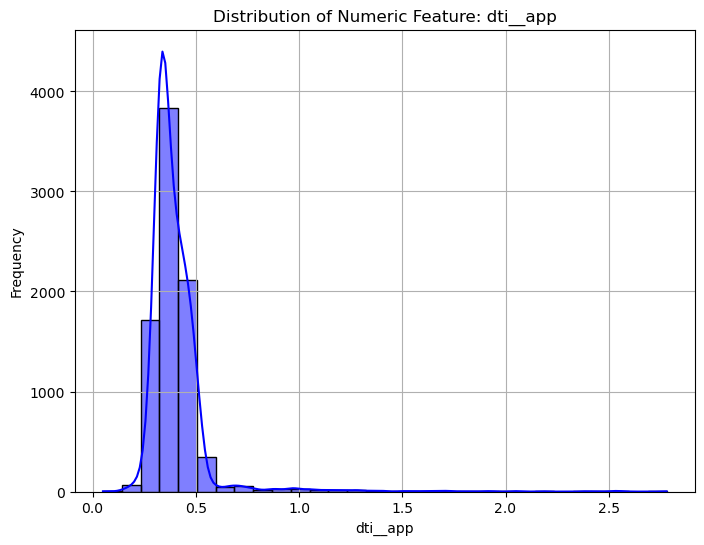

**ENG-bk**


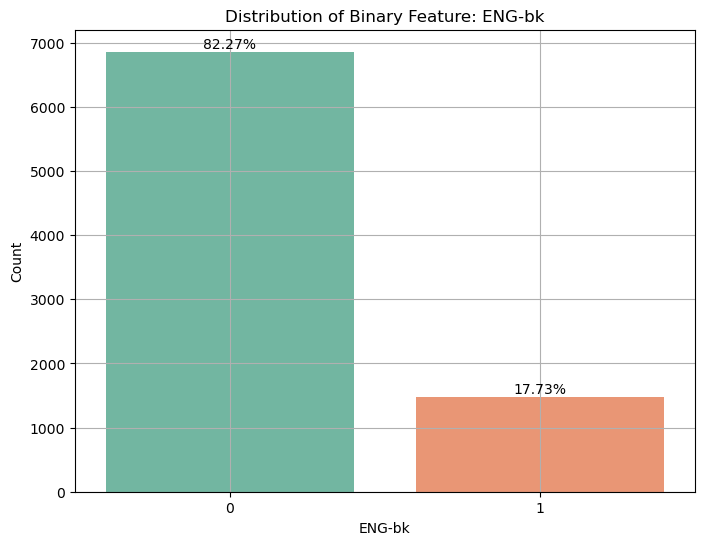

**inquirybanking12month__ln**


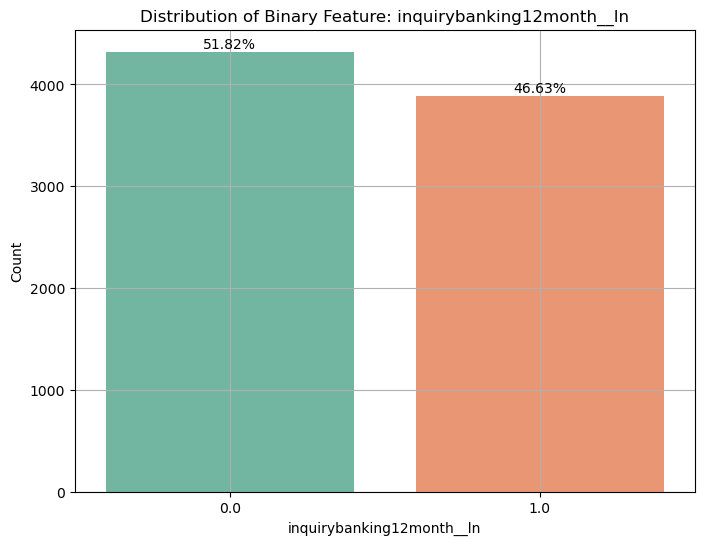

**miles_odometer__app**


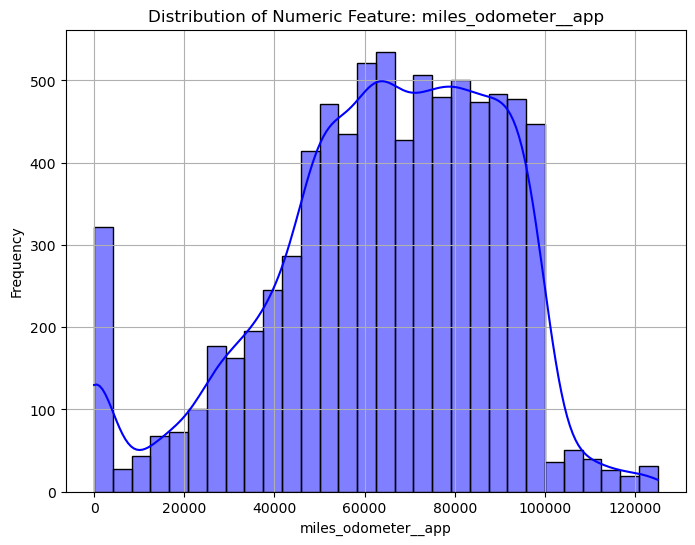

**ENG-loan_to_value**


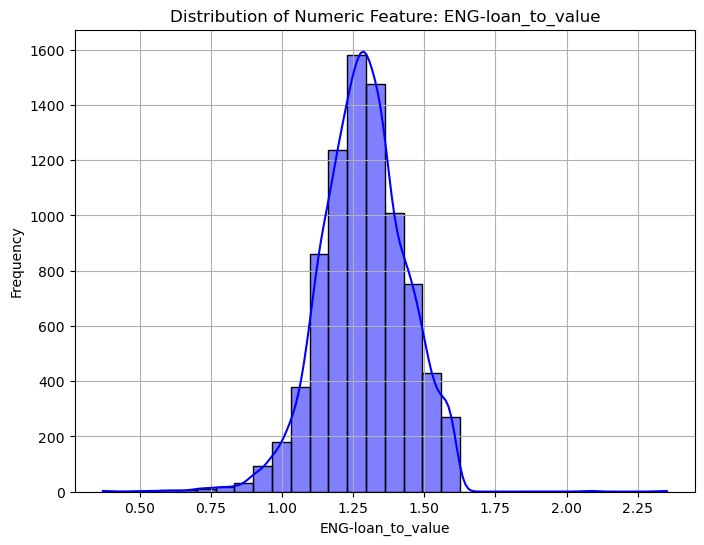

**re01s__tu**


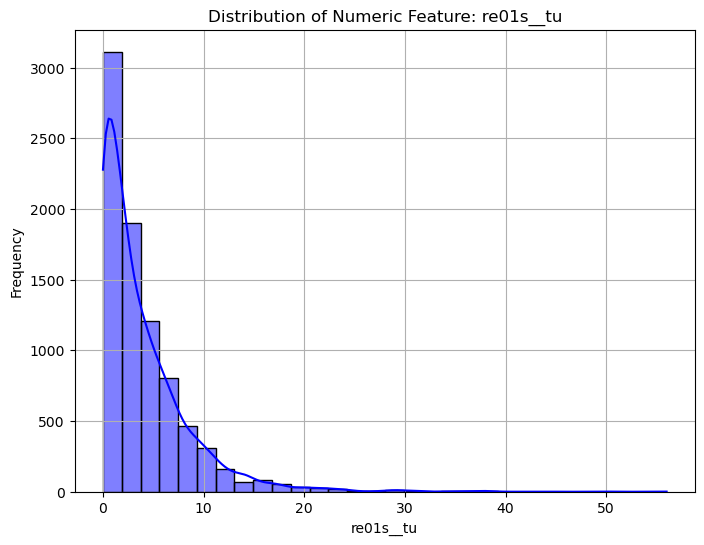

**int_bad_3mo_open__tu_pmthx**


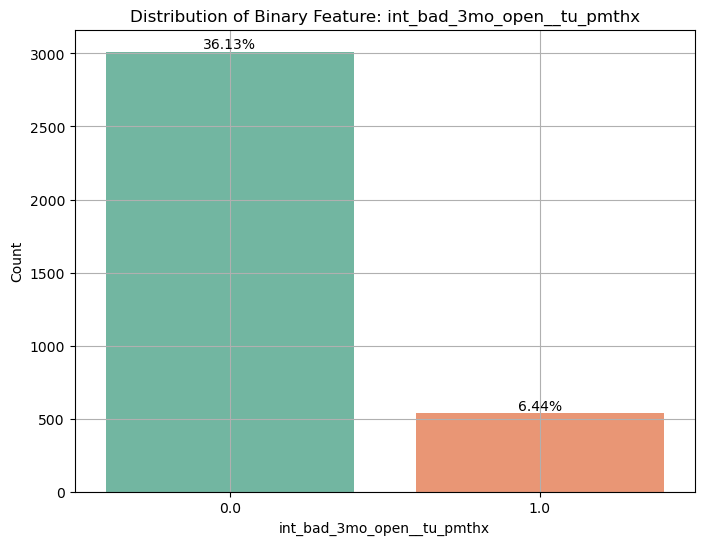

**balmag01__tu**


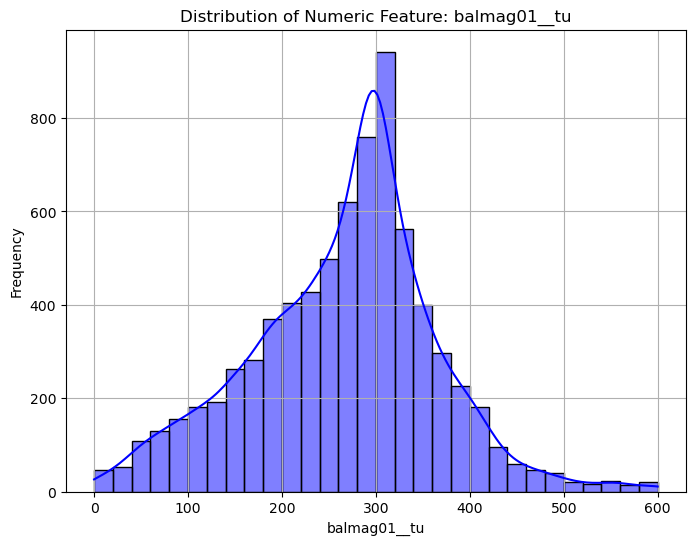

**subjectstabilityindex__ln**


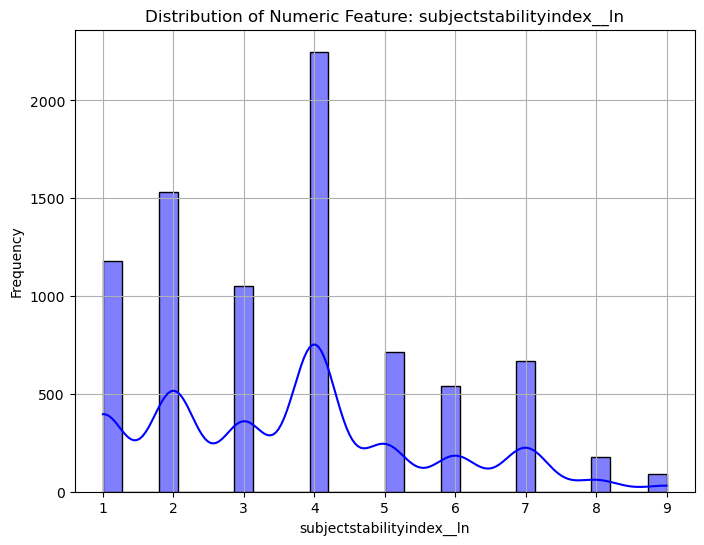

**ENG-franchise**


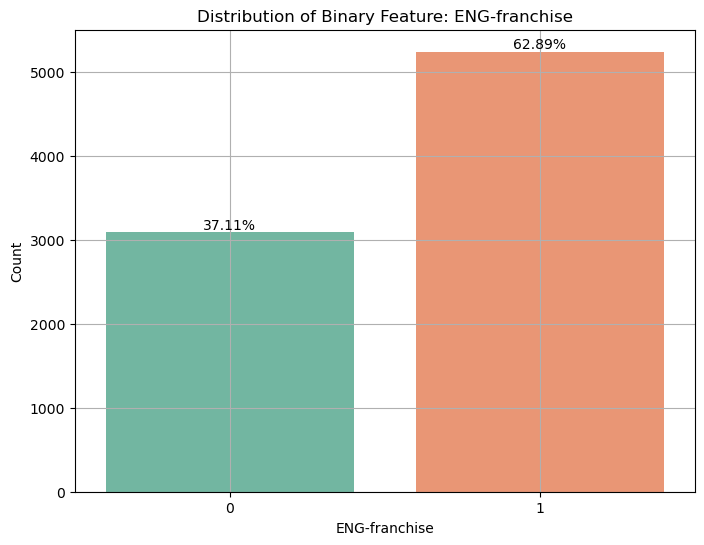

**derogseverityindex__ln**


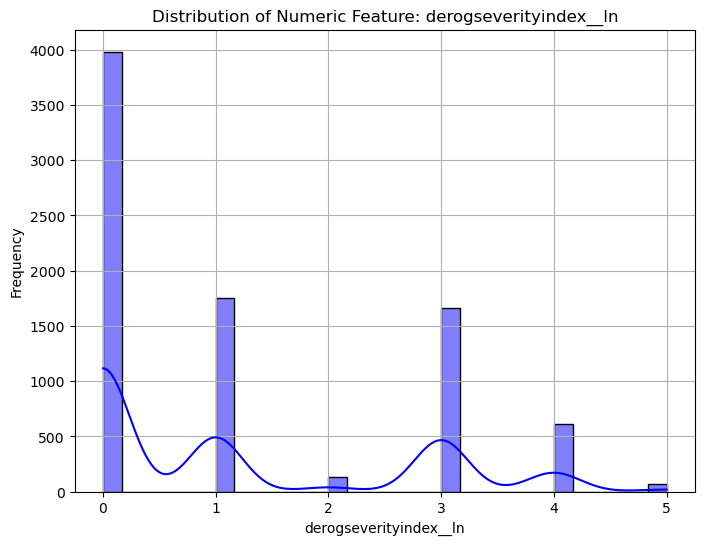

**g414s__tu**


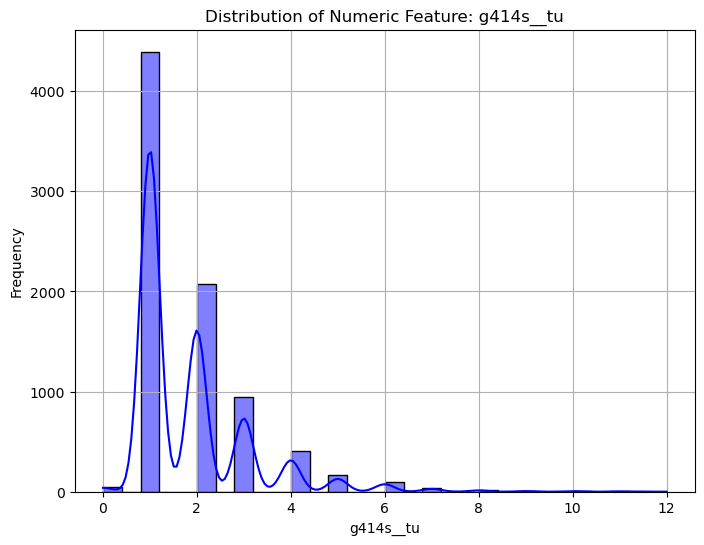

**g106s__tu**


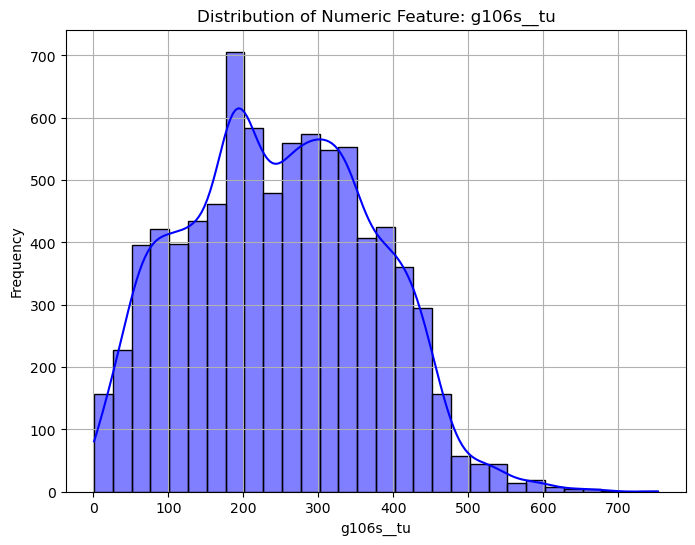

**rp01s__tu**


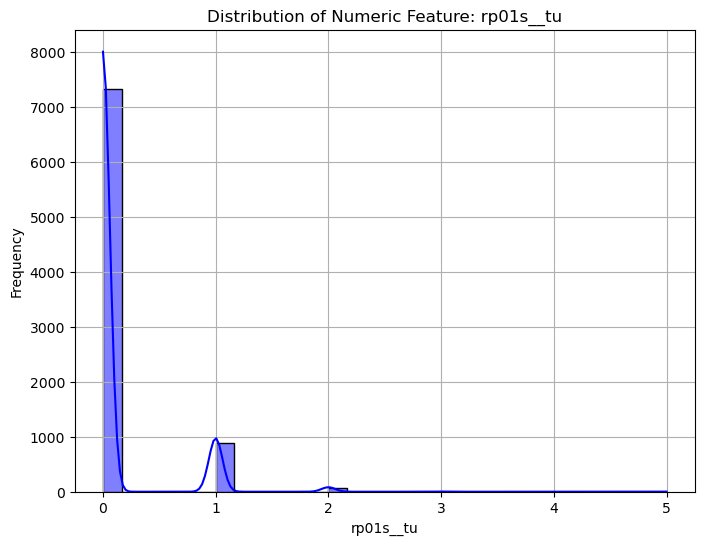

**flt_wtd_avg_open__tu_pmthx**


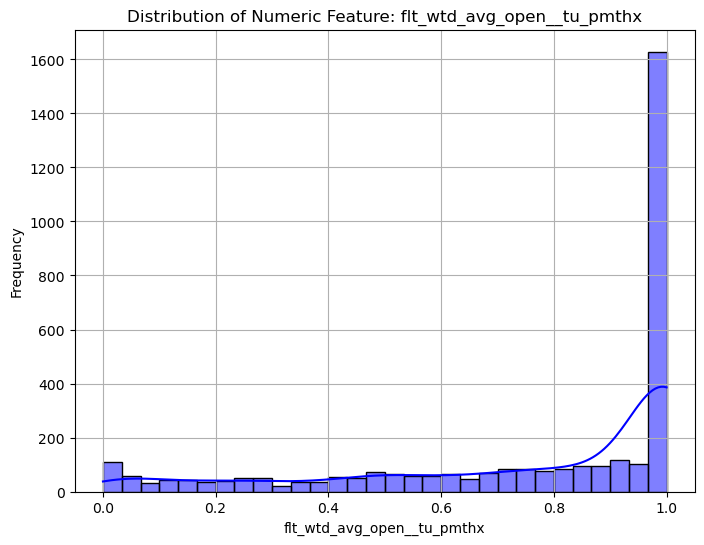

**addrlastmoveecontrajectoryindex__ln**


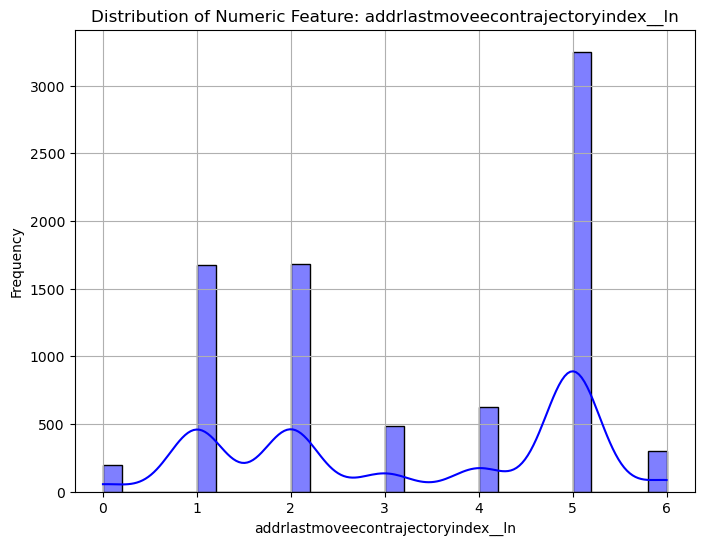

**evictioncount__ln**


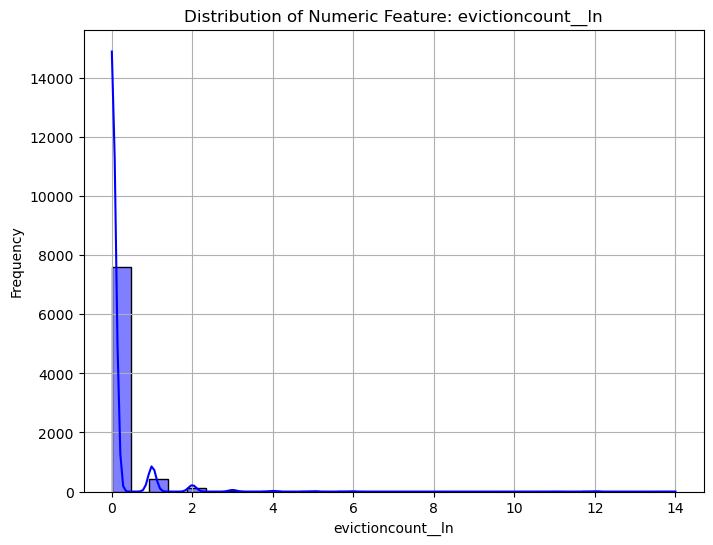

**flt_wtd_avg_closed__tu_pmthx**


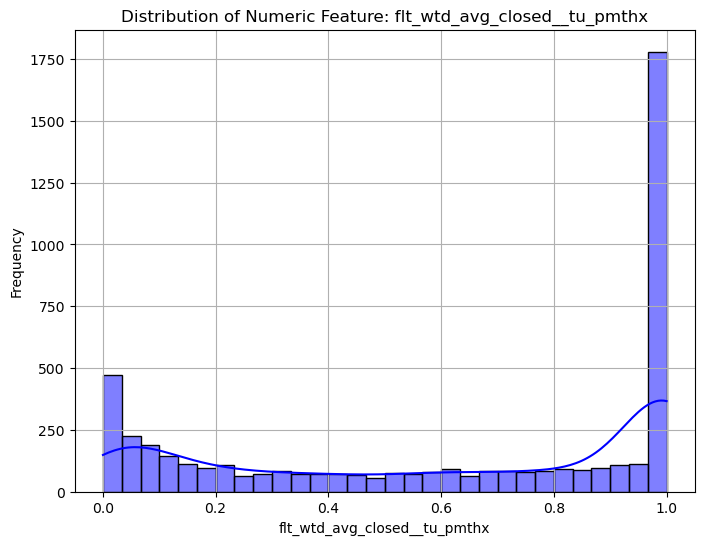

**int_bad_3mo_closed__tu_pmthx**


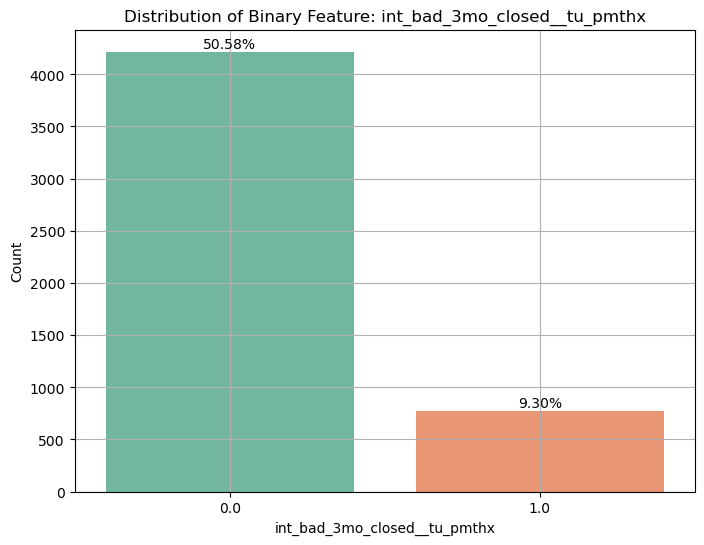

**int_bad_6mo_open_end__tu_pmthx**


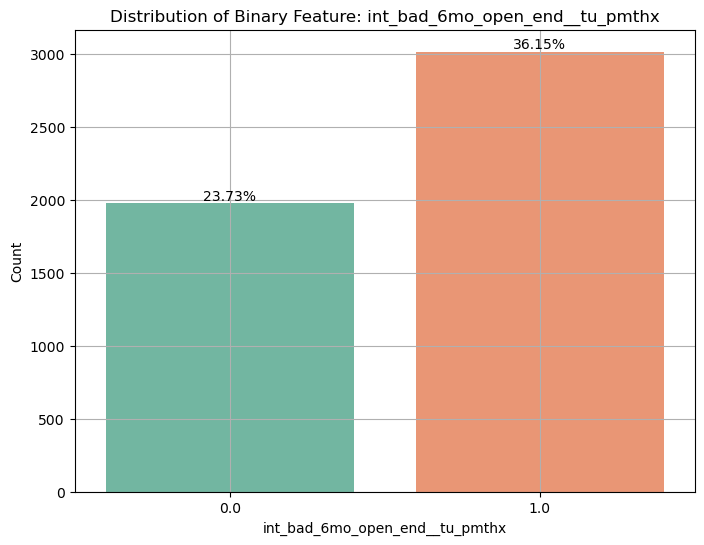

In [46]:
plot_feat_distribution('Test', Test, df_explained, list_cols_model)